# Day 5 — practice and rating, four streams

Pre-registered in D3.11. P5 remains the **stream 1** result; the rest are secondary or exploratory.

| # | Stream | Status | Sees | Runs |
|---|---|---|---|---|
| 1 | Human rater (JS) | **confirmatory — P5** | diagram + text | Parts 5–8 |
| 2 | LLM rater, independent | exploratory | text only | Part 10, chat batches, after stream 1 |
| 3 | LLM audit of stream 1's reasoning | exploratory | text + stream 1's rating and reason | Part 11, chat batches |

**Single human rater.** The 10 unmarked duplicates measure intra-rater consistency. Inter-rater
reliability is not measured, and agreement with the LLM is not a substitute: it sees text only and
applies the rater's own written rubric, so it tests whether the criteria are articulable rather
than whether they are shared.

**Blinding.** Stream 1 runs first and alone. Streams 2 and 3 only after all 50 of stream 1 are
recorded — a mid-run correction would mean the 50 were rated under two standards, and the duplicate
kappa would measure training rather than consistency. Nothing prints a metric until Part 12.

**No graphs are saved.** Weights occupy 18 GB of the 20 GB quota. Each graph is attributed when
shown and discarded; the **text** shown is stored, which is what streams 2 and 3 consume.

### Rubric (D3.8, unchanged)

| | |
|---|---|
| **2** | a causal path from input to output, stated in one sentence, naming the intermediate features |
| **1** | at least one meaningful intermediate feature identifiable, but no complete path |
| **0** | neither |

**Two mechanical checks before awarding a 2:** the trace footer reports ≥ 1 cross-position edge,
**and** a named feature in the chain sits at a non-final position.

## Part 0 — Install

In [1]:
!pip install -q circuit-tracer
print("installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.2/153.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.5/272.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 968.6/968.6 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 kB 4.8 MB/s eta 0:00:00
installed


## Part 1 — Environment and inputs

In [3]:
import os
os.environ["HF_HOME"] = "/kaggle/working/hf"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import sys, time, gc, json, glob, shutil, random, datetime
import numpy as np, pandas as pd

OUT = "/kaggle/working/out"
os.makedirs(OUT, exist_ok=True)

# ---- the single human rater -------------------------------------------------
RATER_ID = "js"
MODALITY = "diagram+text"
print(f"rater={RATER_ID}  modality={MODALITY}")

def find_input(name, required=True):
    hits = glob.glob(f"/kaggle/input/**/{name}", recursive=True) + glob.glob(f"/kaggle/working/{name}")
    if not hits and required:
        raise FileNotFoundError(f"{name} not found. Add Input > Upload a dataset containing it.")
    return hits[0] if hits else None

def free():
    gc.collect()
    try:
        import torch; torch.cuda.empty_cache()
    except Exception:
        pass

corpus = pd.read_csv(find_input("corpus.csv"),
                     dtype={"expected": str, "subtype": str, "prompt": str}, keep_default_na=False)
print(f"corpus {len(corpus)} prompts")

rater=js  modality=diagram+text
corpus 255 prompts


In [4]:
import torch, matplotlib.pyplot as plt
if True:
    src = find_input("ct_utils.py")
    if os.path.abspath(src) != "/kaggle/working/ct_utils.py":
        shutil.copy(src, "/kaggle/working/ct_utils.py")
    sys.path.insert(0, "/kaggle/working")
    import ct_utils, importlib; importlib.reload(ct_utils)
    from ct_utils import to_np

    from kaggle_secrets import UserSecretsClient
    _t = UserSecretsClient().get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = _t; os.environ["HUGGING_FACE_HUB_TOKEN"] = _t
    from huggingface_hub import login; login(token=_t)
    print("disk:", os.popen("df -h /kaggle/working | awk 'NR==2{print $4\" free\"}'").read().strip())

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


disk: 20G free


## Part 2 — The viewer

In [6]:
%%writefile /kaggle/working/circuit_view.py
"""circuit_view - two readable views of a circuit-tracer attribution graph.

    circuit_map(g, model, n_layers)   position x layer picture of the whole graph
    trace(g, model, n_layers)         backward walk from the predicted logit

Both take a Graph straight from `attribute(...)` or `Graph.from_pt(...)`.

Node layout assumed (as circuit-tracer builds it):
    [features | errors (n_layers * n_tok, layer-major) | tokens | logits]
Feature metadata is `active_features[selected_features[i]] -> (layer, position, feature_id)`.
"""
import numpy as np

try:
    import torch
except ImportError:                                   # plotting-only environments
    torch = None


# --------------------------------------------------------------------------- helpers

def _np(x):
    if torch is not None and torch.is_tensor(x):
        return x.detach().cpu().float().numpy()
    return np.asarray(x)


def _influence(adj, logit_probs, n_logits):
    """Probability-weighted path strength from every node to the logits.

    Uses the GPU when the adjacency is a CUDA tensor, otherwise NumPy. The graph is a
    DAG, so the backward series terminates exactly.
    """
    if torch is not None and torch.is_tensor(adj) and adj.is_cuda:
        A = adj.abs().float()
        A = A / A.sum(1, keepdim=True).clamp_min(1e-30)
        w = torch.zeros(A.shape[0], device=A.device)
        w[-n_logits:] = torch.as_tensor(_np(logit_probs), device=A.device,
                                        dtype=torch.float32)
        v, infl = w.clone(), torch.zeros_like(w)
        for _ in range(500):
            v = v @ A
            infl += v
            if float(v.sum()) < 1e-12:
                break
        return A.cpu().numpy(), infl.cpu().numpy()

    A = np.abs(_np(adj)).astype(np.float32)
    rs = A.sum(1, keepdims=True)
    A = np.divide(A, rs, out=np.zeros_like(A), where=rs > 0)
    w = np.zeros(A.shape[0], dtype=np.float32)
    w[-n_logits:] = _np(logit_probs)
    v, infl = w.copy(), np.zeros_like(w)
    for _ in range(500):
        v = v @ A
        infl += v
        if v.sum() < 1e-12:
            break
    return A, infl


def _unpack(g, model, n_layers):
    af = _np(g.active_features).astype(int)           # (n_active, 3) layer, pos, feature id
    sel = _np(g.selected_features).astype(int)        # indexes into active_features
    meta = af[sel]                                    # (n_feat, 3)
    n_feat = len(sel)
    toks = [model.tokenizer.decode([int(t)]) for t in _np(g.input_tokens).astype(int)]
    nt = len(toks)
    probs = _np(g.logit_probabilities)
    A, infl = _influence(g.adjacency_matrix, probs, len(probs))
    return dict(A=A, infl=infl, meta=meta, n_feat=n_feat, nt=nt, nl=n_layers, toks=toks,
                probs=probs, err0=n_feat, tok0=n_feat + n_layers * nt)


def _predicted(g, model):
    probs = _np(g.logit_probabilities)
    k = int(np.argmax(probs))
    for name in ("logit_token_ids", "logit_tokens", "logit_targets"):
        if hasattr(g, name):
            try:
                tid = int(np.atleast_1d(_np(getattr(g, name))[k]).ravel()[-1])
                return model.tokenizer.decode([tid]), float(probs[k])
            except Exception:
                continue
    return "?", float(probs[k])


def _label(i, d):
    if i < d["n_feat"]:
        lay, pos, fid = d["meta"][i]
        return f"L{lay:02d} pos{pos}({d['toks'][pos]!r}) #{fid}"
    if i < d["tok0"]:
        j = i - d["err0"]
        p = j % d["nt"]
        return f"ERROR L{j // d['nt']:02d} pos{p}({d['toks'][p]!r})"
    if i < d["tok0"] + d["nt"]:
        p = i - d["tok0"]
        return f"TOKEN pos{p} {d['toks'][p]!r}"
    return "LOGIT"


# --------------------------------------------------------------------------- the map

def circuit_map(g, model, n_layers, top_features=40, n_arrows=14, label_top=6,
                figsize=None, ax=None, title=None):
    """Position x layer picture of one attribution graph.

    blue circles  features, placed at (token position, layer), area = influence
    red shading   error-node influence: where the transcoder could not reconstruct
    black arrows  the strongest CROSS-POSITION feature edges - information moving,
                  which is where the mechanism lives
    grey column   the read-out position, which the logits read from
    """
    import matplotlib.pyplot as plt

    d = _unpack(g, model, n_layers)
    infl, meta, n_feat, nt, nl = d["infl"], d["meta"], d["n_feat"], d["nt"], d["nl"]

    err_grid = infl[d["err0"]:d["tok0"]].reshape(nl, nt)
    f_inf = infl[:n_feat]
    f_lay, f_pos = meta[:, 0], meta[:, 1]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize or (max(7, 1.05 * nt + 3), 7))

    ax.imshow(err_grid, cmap="Reds", origin="lower", aspect="auto",
              extent=(-0.5, nt - 0.5, -0.5, nl - 0.5),
              vmin=0, vmax=max(err_grid.max(), 1e-9))
    ax.axvspan(nt - 1.5, nt - 0.5, color="0.5", alpha=0.12, zorder=0)

    keep = np.argsort(-f_inf)[:top_features]
    keep = keep[f_inf[keep] > 0]
    if len(keep):
        ax.scatter(f_pos[keep], f_lay[keep],
                   s=40 + 4000 * f_inf[keep] / max(f_inf.max(), 1e-12),
                   c="#1d4ed8", alpha=0.65, edgecolors="white", linewidths=0.6, zorder=3)

    # strongest cross-position edges among the most influential features
    A = d["A"]
    edges = []
    for i in np.argsort(-f_inf)[:top_features]:
        row = A[i]
        for s in np.argsort(-row)[:4]:
            if s >= n_feat or row[s] <= 0:
                continue
            if meta[s, 1] != meta[i, 1]:              # crosses a token position
                edges.append((float(row[s] * f_inf[i]), int(s), int(i)))
    edges.sort(reverse=True)
    seen = set()
    for _, s, i in edges[:n_arrows]:
        key = (meta[s, 1], meta[s, 0], meta[i, 1], meta[i, 0])
        if key in seen:
            continue
        seen.add(key)
        ax.annotate("", xy=(meta[i, 1], meta[i, 0]), xytext=(meta[s, 1], meta[s, 0]),
                    arrowprops=dict(arrowstyle="-|>", color="#111827", lw=1.3,
                                    alpha=0.75, shrinkA=6, shrinkB=6,
                                    connectionstyle="arc3,rad=0.12"), zorder=4)

    for i in np.argsort(-f_inf)[:label_top]:
        ax.annotate(f"#{meta[i, 2]}", (f_pos[i], f_lay[i]), fontsize=7, color="#1e3a8a",
                    xytext=(5, 5), textcoords="offset points", zorder=5)

    ax.set_xticks(range(nt))
    ax.set_xticklabels([t.replace("\n", "\\n") for t in d["toks"]], rotation=45,
                       ha="right", fontsize=9)
    ax.set_yticks(range(0, nl, 2))
    ax.set_ylabel("layer")
    ax.set_xlim(-0.5, nt - 0.5)
    ax.set_ylim(-0.5, nl - 0.5)

    pred, p = _predicted(g, model)
    if title is None:
        title = f"{getattr(g, 'input_string', '')!r}\npredicts {pred!r}  (p={p:.2f})"
    ax.set_title(title, fontsize=10, loc="left")

    # one-line orientation summary under the plot
    tok_inf = infl[d["tok0"]:d["tok0"] + nt]
    third = nl // 3
    early = f_inf[f_lay < third].sum()
    mid = f_inf[(f_lay >= third) & (f_lay < 2 * third)].sum()
    late = f_inf[f_lay >= 2 * third].sum()
    ax.set_xlabel(
        f"token influence peak: {d['toks'][int(np.argmax(tok_inf))]!r}   |   "
        f"error peak: {d['toks'][int(np.argmax(err_grid.sum(0)))]!r} "
        f"({err_grid.sum(0).max() / max(err_grid.sum(), 1e-12):.0%} of error)   |   "
        f"feature influence  early {early:.2f}  mid {mid:.2f}  late {late:.2f}",
        fontsize=8)
    return ax


# ------------------------------------------------------------------------- the trace

def summary(g, model, n_layers, _d=None):
    """Orientation block: prediction, token influence, error by position, layer thirds.

    Read this BEFORE the diagram. It answers, in four lines: did the model do the task,
    where did the answer come from, where did the method go blind, and did anything
    abstract happen in the middle layers.
    """
    d = _d or _unpack(g, model, n_layers)
    infl, meta, n_feat, nt, nl, toks = (d["infl"], d["meta"], d["n_feat"],
                                        d["nt"], d["nl"], d["toks"])
    pred, p = _predicted(g, model)
    tok_inf = infl[d["tok0"]:d["tok0"] + nt]
    err_pos = infl[d["err0"]:d["tok0"]].reshape(nl, nt).sum(0)
    f_lay, f_inf = meta[:, 0], infl[:n_feat]
    t3 = nl // 3
    early, mid, late = (f_inf[f_lay < t3].sum(),
                        f_inf[(f_lay >= t3) & (f_lay < 2 * t3)].sum(),
                        f_inf[f_lay >= 2 * t3].sum())
    peak_tok = toks[int(np.argmax(tok_inf))]
    peak_err = toks[int(np.argmax(err_pos))]
    return "\n".join([
        f"prompt   : {getattr(g, 'input_string', '')!r}",
        f"predicts : {pred!r}  (p={p:.2f})",
        "token influence  : " + ", ".join(f"{toks[i]!r} {tok_inf[i]:.3f}" for i in range(nt)),
        "error by position: " + ", ".join(f"{toks[i]!r} {err_pos[i]:.3f}" for i in range(nt)),
        f"feature influence: early {early:.3f}  mid {mid:.3f}  late {late:.3f}"
        f"   (mid/early {mid / max(early, 1e-12):.2f})",
        f"peak token influence {peak_tok!r} | peak error {peak_err!r} | "
        f"read-out position holds {err_pos[-1] / max(err_pos.sum(), 1e-12):.0%} of all error",
    ])


def describe(g, model, n_layers, depth=4, width=4, min_w=0.01, keep_min=3, labels=None):
    """The whole graph as text: prediction, orientation summaries, and a deduped
    backward trace from the logit. Returned as a string so it can be printed and
    also stored (e.g. for a second rater)."""
    d = _unpack(g, model, n_layers)
    A, probs, meta = d["A"], d["probs"], d["meta"]
    n_feat, nt, nl, toks = d["n_feat"], d["nt"], d["nl"], d["toks"]
    infl = d["infl"]
    labels = labels or {}
    pred, p = _predicted(g, model)
    L = summary(g, model, n_layers, _d=d).split("\n")
    L.append("")

    def lab(i):
        base = _label(i, d)
        if i < n_feat:
            key = (int(meta[i, 0]), int(meta[i, 2]))
            if key in labels and labels[key]:
                return f"{base}  \u00ab{labels[key][:48]}\u00bb"
        return base

    k = int(np.argmax(probs))
    logit = A.shape[0] - len(probs) + k
    expanded, cross = set(), 0
    L.append("")
    L.append(f"LOGIT {pred!r}")

    def walk(i, left, pre):
        nonlocal cross
        if left == 0 or d["err0"] <= i < d["tok0"] + nt:
            return
        for s, w in _top_inputs(A[i], width, min_w, keep_min):
            both = s < n_feat and i < n_feat
            crosses = both and meta[s, 1] != meta[i, 1]
            cross += crosses
            seen = s in expanded and s < n_feat   # only features get expanded
            L.append(f"{pre}<-{' *' if crosses else '  '}{w:.3f}  {lab(s)}"
                     + ("   (expanded above)" if seen else ""))
            if not seen:
                expanded.add(s)
                walk(s, left - 1, pre + "    ")

    walk(logit, depth, "  ")
    L.append("")
    L.append(f"* = crosses a token position ({cross} such edges drawn)")
    return "\n".join(L)


def trace(g, model, n_layers, depth=4, width=4, min_w=0.01, keep_min=3, labels=None):
    print(describe(g, model, n_layers, depth, width, min_w, keep_min, labels))


# ------------------------------------------------------------------- path diagram

def _top_inputs(row, width, min_w, keep_min):
    """Top-`width` inputs of a node. `min_w` only trims BEYOND the first `keep_min`.

    Row weights are normalised per node, so a high fan-in node (the logit has
    thousands of incoming edges) has tiny weights throughout - a fixed threshold
    there silently empties the graph.
    """
    order = np.argsort(-row)[:width]
    out = []
    for rank, s in enumerate(order):
        w = float(row[s])
        if w <= 0:
            break
        if rank < keep_min or w >= min_w:
            out.append((int(s), w))
    return out


def _back_edges(d, depth=4, width=4, min_w=0.01, keep_min=3):
    """Backward-reachable subgraph from the predicted logit: (src, dst, weight)."""
    A, probs = d["A"], d["probs"]
    k = int(np.argmax(probs))
    logit = A.shape[0] - len(probs) + k
    edges, seen = [], set()

    def walk(i, left):
        if left == 0 or d["err0"] <= i < d["tok0"] + d["nt"]:
            return
        for s, w in _top_inputs(A[i], width, min_w, keep_min):
            edges.append((s, i, w))
            if (s, left) not in seen:
                seen.add((s, left))
                walk(s, left - 1)

    walk(logit, depth)
    return logit, edges


def path_diagram(g, model, n_layers, depth=4, width=4, min_w=0.01, keep_min=3,
                 labels=None, figsize=None, ax=None):
    """Only the nodes that feed the answer, placed by token position and layer.

    Every node is labelled. Edge thickness is the normalised attribution weight.
    Bold black edges cross a token position - that is information moving, and it is
    where the mechanism lives. `labels` may be a {(layer, feature_id): text} dict,
    e.g. from Neuronpedia, in which case the text replaces the bare feature id.
    """
    import matplotlib.pyplot as plt

    d = _unpack(g, model, n_layers)
    meta, n_feat, nt, nl, toks = d["meta"], d["n_feat"], d["nt"], d["nl"], d["toks"]
    act = _np(g.activation_values) if hasattr(g, "activation_values") else None
    logit, edges = _back_edges(d, depth, width, min_w, keep_min)

    def coord(i):
        if i < n_feat:
            return float(meta[i, 1]), float(meta[i, 0])
        if i < d["tok0"]:
            j = i - d["err0"]
            return float(j % nt), float(j // nt)
        if i < d["tok0"] + nt:
            return float(i - d["tok0"]), -2.0
        return float(nt - 1), float(nl + 2)

    def text(i):
        if i < n_feat:
            lay, pos, fid = meta[i]
            a = f"\nact {act[i]:.0f}" if act is not None and i < len(act) else ""
            if labels and (int(lay), int(fid)) in labels:
                return f"L{lay} {labels[(int(lay), int(fid))][:34]}{a}"
            return f"L{lay} #{fid}{a}"
        if i < d["tok0"]:
            j = i - d["err0"]
            return f"ERROR L{j // nt}"
        if i < d["tok0"] + nt:
            return f"{toks[i - d['tok0']]!r}"
        return "LOGIT"

    nodes = sorted({s for s, _, _ in edges} | {t for _, t, _ in edges} | {logit})
    # spread nodes that share a cell so labels do not collide
    cells, xy = {}, {}
    for i in nodes:
        x, y = coord(i)
        k = (round(x), round(y))
        cells.setdefault(k, []).append(i)
    for (x, y), group in cells.items():
        for r, i in enumerate(group):
            xy[i] = (x + 0.30 * (r - (len(group) - 1) / 2), y + 0.55 * (r % 2))

    # push apart nodes that share a token column, so the labels stay legible
    MIN_GAP = max(2.0, nl / 12)
    for x0 in {round(v[0]) for v in xy.values()}:
        col = sorted([i for i in xy if round(xy[i][0]) == x0], key=lambda i: xy[i][1])
        for a, b in zip(col, col[1:]):
            if xy[b][1] - xy[a][1] < MIN_GAP:
                xy[b] = (xy[b][0], xy[a][1] + MIN_GAP)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize or (max(9, 1.45 * nt), 10))

    for s, t, w in edges:
        if s not in xy or t not in xy:
            continue
        crosses = (s < n_feat and t < n_feat and meta[s, 1] != meta[t, 1])
        ax.annotate("", xy=xy[t], xytext=xy[s], zorder=2,
                    arrowprops=dict(arrowstyle="-|>", lw=0.8 + 4 * w,
                                    color="#111827" if crosses else "#9ca3af",
                                    alpha=0.9 if crosses else 0.55,
                                    shrinkA=12, shrinkB=12,
                                    connectionstyle="arc3,rad=0.1"))

    for i in nodes:
        x, y = xy[i]
        if i >= d["tok0"] + nt:
            fc, ec = "#bbf7d0", "#15803d"
        elif i >= d["tok0"]:
            fc, ec = "#e5e7eb", "#6b7280"
        elif i >= d["err0"]:
            fc, ec = "#fecaca", "#b91c1c"
        else:
            fc, ec = "#dbeafe", "#1d4ed8"
        ax.annotate(text(i), (x, y), ha="center", va="center", fontsize=7.5, zorder=3,
                    bbox=dict(boxstyle="round,pad=0.35", fc=fc, ec=ec, lw=1.0))

    ax.set_xticks(range(nt))
    ax.set_xticklabels([t.replace("\n", "\\n") for t in toks], rotation=45, ha="right", fontsize=9)
    ax.set_yticks(list(range(0, nl, 4)) + [-2, nl + 2])
    ax.set_yticklabels([str(v) for v in range(0, nl, 4)] + ["token", "logit"], fontsize=8)
    ax.set_xlim(-0.8, nt - 0.2); ax.set_ylim(-3.5, max(nl + 3.5, max(v[1] for v in xy.values()) + 2))
    ax.set_ylabel("layer"); ax.grid(axis="x", alpha=0.15)
    pred, p = _predicted(g, model)
    ax.set_title(f"{getattr(g, 'input_string', '')!r}  ->  {pred!r} (p={p:.2f})\n"
                 f"blue feature, red error, grey token, green logit; "
                 f"bold edge = crosses a token position", fontsize=9, loc="left")
    return ax


# ------------------------------------------------------- Neuronpedia feature labels

NP_TEMPLATE = ("https://www.neuronpedia.org/api/feature/"
               "gemma-2-2b/{layer}-gemmascope-transcoder-16k/{fid}")
NP_CACHE = "/kaggle/working/np_labels.json"


def _load_cache(path=None):
    import json, os
    path = path or NP_CACHE
    if os.path.exists(path):
        try:
            return {tuple(int(x) for x in k.split("_")): v
                    for k, v in json.load(open(path)).items()}
        except Exception:
            pass
    return {}


def _save_cache(cache, path=None):
    import json, os
    path = path or NP_CACHE
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    json.dump({f"{l}_{f}": v for (l, f), v in cache.items()}, open(path, "w"))


def fetch_labels(pairs, template=None, cache_path=None, pause=0.15,
                 timeout=10, verbose=False):
    """Feature descriptions from Neuronpedia for [(layer, feature_id), ...].

    Cached on disk, so each feature is fetched once per session. Failures are cached
    as None and not retried; a missing label never blocks a rating.
    """
    import time as _t
    import requests

    template = template or NP_TEMPLATE
    cache = _load_cache(cache_path)
    todo = [p for p in set(pairs) if p not in cache]
    for lay, fid in todo:
        try:
            r = requests.get(template.format(layer=int(lay), fid=int(fid)), timeout=timeout)
            if r.ok:
                exps = r.json().get("explanations") or []
                cache[(lay, fid)] = (exps[0].get("description") if exps else None)
            else:
                cache[(lay, fid)] = None
        except Exception as ex:
            if verbose:
                print("label fetch failed", lay, fid, type(ex).__name__)
            cache[(lay, fid)] = None
        _t.sleep(pause)
    if todo:
        try:
            _save_cache(cache, cache_path)
        except Exception as ex:
            if verbose:
                print("cache write failed:", type(ex).__name__)
    return {k: v for k, v in cache.items() if v}


def auto_labels(g, model, n_layers, depth=4, width=4, min_w=0.01, keep_min=3, **kw):
    """Fetch labels for exactly the features the path diagram will draw."""
    d = _unpack(g, model, n_layers)
    _, edges = _back_edges(d, depth, width, min_w, keep_min)
    ids = {i for e in edges for i in (e[0], e[1]) if i < d["n_feat"]}
    pairs = [(int(d["meta"][i, 0]), int(d["meta"][i, 2])) for i in ids]
    return fetch_labels(pairs, **kw)


def explain(g, model, n_layers, depth=4, width=4, min_w=0.01, keep_min=3,
            labels=None, show=True, diagram=True):
    """Labelled path diagram plus the text description - the view to rate from.

    Returns {"text": ..., "labels": ...} so the text can be stored for a second rater.
    """
    import matplotlib.pyplot as plt
    if labels is None:
        try:
            labels = auto_labels(g, model, n_layers, depth, width, min_w, keep_min)
        except Exception as ex:
            print(f"(no labels: {type(ex).__name__}; is notebook internet on?)")
            labels = {}
    d = _unpack(g, model, n_layers)
    print(summary(g, model, n_layers, _d=d))          # orientation BEFORE the picture
    print()
    if diagram:
        path_diagram(g, model, n_layers, depth=depth, width=width, min_w=min_w,
                     keep_min=keep_min, labels=labels)
        if show:
            plt.show()
    text = describe(g, model, n_layers, depth, width, min_w, keep_min, labels)
    print(text[text.index("LOGIT "):] if "LOGIT " in text else text)
    named = sum(1 for v in labels.values() if v)
    print(f"\n{named} of the drawn features have a Neuronpedia description.")
    return {"text": text, "labels": {f"{l}_{f}": v for (l, f), v in labels.items()}}


Overwriting /kaggle/working/circuit_view.py


In [5]:
sys.path.insert(0, "/kaggle/working")
if True:
    import circuit_view; importlib.reload(circuit_view)
    from circuit_view import explain, fetch_labels
    circuit_view.NP_CACHE = f"{OUT}/np_labels.json"
    probe = fetch_labels([(14, 8997)], verbose=True)
    LABELS_OK = bool(probe)
    print("labels available:", LABELS_OK, "|", probe)
    if not LABELS_OK:
        print("Internet may be off (Settings > Internet), or the source slug changed.")

labels available: True | {(14, 8997): ' references to Cuba, sugar, and diabetes'}


## Part 3 — Model

In [7]:
from circuit_tracer import ReplacementModel, attribute
if True:
    CFG = json.load(open(find_input("day3_config.json")))
    AK = CFG["attr_kwargs"]; NL = CFG["n_layers"]
    DEPTH, WIDTH, MIN_W, KEEP_MIN = 4, 4, 0.01, 3      # identical for every presentation
    model = ReplacementModel.from_pretrained("google/gemma-2-2b", "gemma", backend="nnsight",
                                             dtype=torch.bfloat16, device="cuda",
                                             lazy_encoder=True)
    print("model loaded")

config.yaml:   0%|          | 0.00/202 [00:00<?, ?B/s]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

layer_12.safetensors:   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_1.safetensors:   0%|          | 0.00/302M [00:00<?, ?B/s]

layer_11.safetensors:   0%|          | 0.00/302M [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/481M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

model loaded


## Part 4 — Blind selection

Reads `results.csv` for the quantile bins, then discards the scores. An existing manifest is reused,
so a restarted session cannot change which 50 are rated — and stream 2 rates exactly the same 50.

In [8]:
MAN = f"{OUT}/rating_manifest.csv"

if os.path.exists(MAN) or find_input("rating_manifest.csv", required=False):
    manifest = pd.read_csv(MAN if os.path.exists(MAN) else find_input("rating_manifest.csv"),
                           dtype={"prompt": str, "subtype": str}, keep_default_na=False)
    manifest.to_csv(MAN, index=False)
    print(f"existing manifest reused: {len(manifest)} presentations")
else:
    results = pd.read_csv(find_input("results.csv"), keep_default_na=False)
    ok = results[results.status == "ok"].copy()
    ok["replacement_score"] = ok.replacement_score.astype(float)
    ok["bin"] = pd.qcut(ok.replacement_score, 8, labels=False, duplicates="drop")
    sel = ok.groupby("bin", group_keys=False).sample(5, random_state=0)[["prompt_id", "bin"]]
    assert len(sel) == 40, f"selected {len(sel)}"
    rng = random.Random(0)
    dups = rng.sample(list(sel.prompt_id), 10)
    pres = list(sel.prompt_id) + dups
    rng.shuffle(pres)
    manifest = pd.DataFrame({"presentation": range(1, len(pres) + 1), "prompt_id": pres}) \
        .merge(corpus[["prompt_id", "category", "subtype", "prompt", "n_tok"]],
               on="prompt_id", how="left")
    manifest.to_csv(MAN, index=False)
    sel.assign(is_duplicate_source=sel.prompt_id.isin(dups)).to_csv(
        f"{OUT}/rating_key_SEALED.csv", index=False)
    del results, ok, sel; free()
    print(f"{len(manifest)} presentations, {manifest.prompt_id.nunique()} unique graphs")

print(manifest.groupby("category").size().to_string())
print("\nno metric columns:", list(manifest.columns))

50 presentations, 40 unique graphs
category
arithmetic              10
code_completion          4
entity_known_unknown     8
factual_recall           5
induction                6
multi_hop                6
obfuscated               7
syntactic_agreement      4

no metric columns: ['presentation', 'prompt_id', 'category', 'subtype', 'prompt', 'n_tok']


## Part 5 — Practice (stream 1 only)

Five prompts **excluded from the rated sample**, so nothing here contaminates a rating.

Reading order: the summary block answers *did it do the task, where did the answer come from, where
did the method go blind, did anything abstract happen*. Then the diagram: blue features at (token
position, layer), red error nodes, **bold edges cross a token position**. Then the trace, read
top-down as the sentence you would write.

In [10]:
excluded = set(manifest.prompt_id)
if True:
    practice = (corpus[~corpus.prompt_id.isin(excluded)
                       & corpus.category.isin(["factual_recall", "arithmetic", "multi_hop",
                                               "induction", "obfuscated"])]
                .groupby("category", group_keys=False).sample(1, random_state=2))
    assert not (set(practice.prompt_id) & excluded)
    print(practice[["prompt_id", "category", "n_tok", "prompt"]].to_string(index=False))

    def practise(i):
        row = practice.iloc[i]
        print(f"--- practice {i+1}/{len(practice)}   {row.prompt_id}  [{row.category}] ---")
        g = attribute(prompt=row.prompt, model=model, **AK)
        out = explain(g, model, NL, depth=DEPTH, width=WIDTH, min_w=MIN_W, keep_min=KEEP_MIN)
        del g; free()
        with open(f"{OUT}/practice_texts.jsonl", "a") as f:
            f.write(json.dumps({"prompt_id": row.prompt_id, "category": row.category,
                                "text": out["text"]}) + "\n")

prompt_id       category  n_tok                                                        prompt
    p0052     arithmetic     10                                                The sum 36+59=
    p0037 factual_recall      9                      Fact: Serena Williams plays the sport of
    p0165      induction     16                     snerrik yolvantz snerrik yolvantz snerrik
    p0125      multi_hop     13 Someone who grew up in the city of Tokyo would normally speak
    p0217     obfuscated     10                                         PlEaSe oPeN tHe Front


In [11]:
PRACTISED = set()          # run once, at the top of your session

def new_practice(seed, cats=None, n=1):
    cats = cats or ["factual_recall", "arithmetic", "multi_hop", "induction", "obfuscated"]
    pool = corpus[~corpus.prompt_id.isin(set(manifest.prompt_id) | PRACTISED)
                  & corpus.category.isin(cats)]
    sel = pool.groupby("category", group_keys=False).sample(n, random_state=seed)
    PRACTISED.update(sel.prompt_id)
    assert not (set(sel.prompt_id) & set(manifest.prompt_id))
    return sel.reset_index(drop=True)

practice = new_practice(2)
print(practice[["prompt_id", "category", "n_tok", "prompt"]].to_string(index=False))

prompt_id       category  n_tok                                                        prompt
    p0052     arithmetic     10                                                The sum 36+59=
    p0037 factual_recall      9                      Fact: Serena Williams plays the sport of
    p0165      induction     16                     snerrik yolvantz snerrik yolvantz snerrik
    p0125      multi_hop     13 Someone who grew up in the city of Tokyo would normally speak
    p0217     obfuscated     10                                         PlEaSe oPeN tHe Front


In [12]:
practice = new_practice(2, cats=["code_completion", "entity_known_unknown",
                                 "syntactic_agreement"], n=2)

In [ ]:
practice

--- practice 2/5   p0037  [factual_recall] ---
prompt   : '<bos>Fact: Serena Williams plays the sport of'
predicts : ' tennis'  (p=0.95)
token influence  : '<bos>' 0.115, 'Fact' 0.096, ':' 0.046, ' Serena' 0.137, ' Williams' 0.103, ' plays' 0.072, ' the' 0.030, ' sport' 0.070, ' of' 0.014
error by position: '<bos>' 0.000, 'Fact' 0.016, ':' 0.025, ' Serena' 0.025, ' Williams' 0.059, ' plays' 0.026, ' the' 0.011, ' sport' 0.025, ' of' 0.083
feature influence: early 1.275  mid 0.216  late 0.449   (mid/early 0.17)
peak token influence ' Serena' | peak error ' of' | read-out position holds 31% of all error



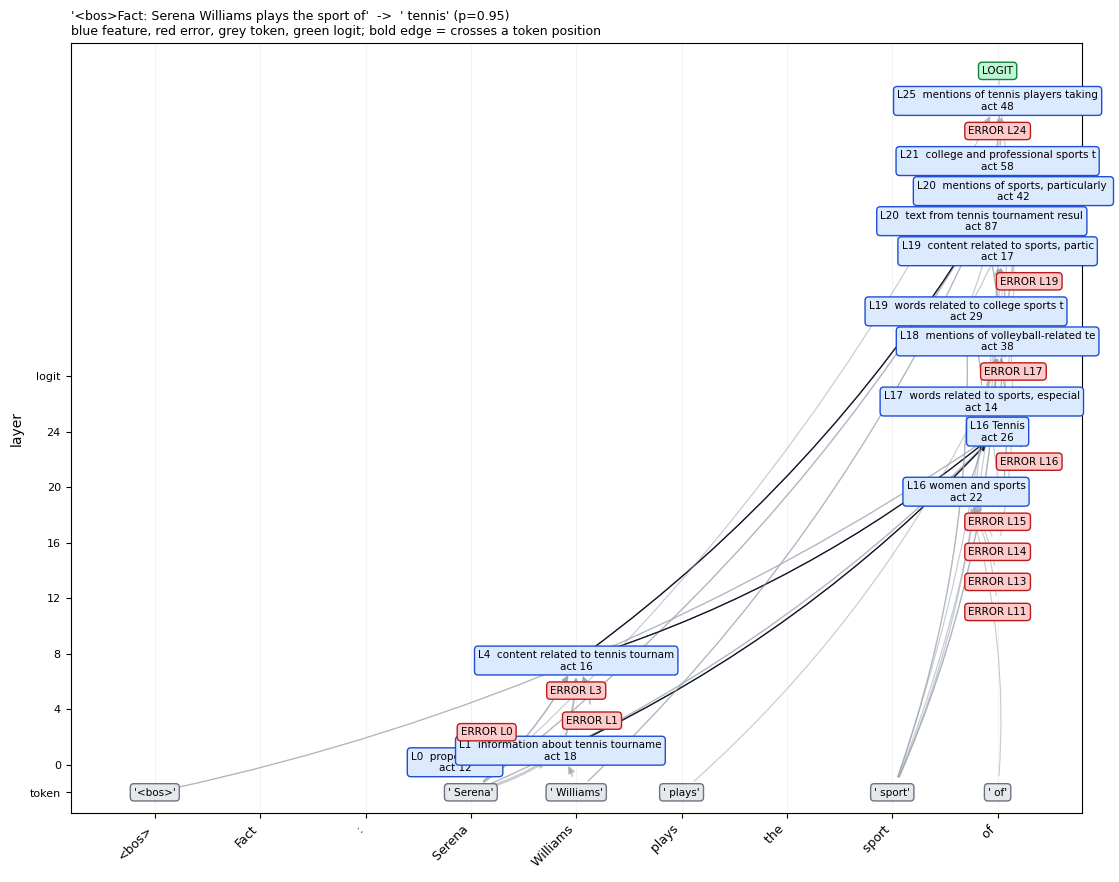

LOGIT ' tennis'
  <-  0.028  L20 pos8(' of') #1483  « text from tennis tournament results»
      <-  0.027  TOKEN pos3 ' Serena'
      <-  0.025  L16 pos8(' of') #13610  «Tennis»
          <-  0.026  TOKEN pos3 ' Serena'
          <-  0.016  TOKEN pos0 '<bos>'
          <- *0.015  L01 pos4(' Williams') #4691  « information about tennis tournaments»
              <-  0.325  TOKEN pos3 ' Serena'
              <-  0.158  TOKEN pos4 ' Williams'
              <- *0.041  L00 pos3(' Serena') #7532  « proper nouns»
              <-  0.032  ERROR L00 pos3(' Serena')
          <- *0.012  L04 pos4(' Williams') #12408  « content related to tennis tournaments»
              <-  0.094  L01 pos4(' Williams') #4691  « information about tennis tournaments»   (expanded above)
              <-  0.059  TOKEN pos3 ' Serena'
              <-  0.035  ERROR L03 pos4(' Williams')
              <-  0.030  ERROR L01 pos4(' Williams')
      <-  0.018  TOKEN pos4 ' Williams'
      <- *0.015  L04 pos4(' Williams') 

In [38]:
practise(1)

--- practice 3/5   p0165  [induction] ---
prompt   : '<bos>snerrik yolvantz snerrik yolvantz snerrik'
predicts : ' yol'  (p=0.95)
token influence  : '<bos>' 0.112, 's' 0.057, 'ner' 0.082, 'rik' 0.059, ' yol' 0.106, 'vant' 0.042, 'z' 0.030, ' s' 0.035, 'ner' 0.033, 'rik' 0.023, ' yol' 0.066, 'vant' 0.013, 'z' 0.013, ' s' 0.020, 'ner' 0.021, 'rik' 0.016
error by position: '<bos>' 0.000, 's' 0.004, 'ner' 0.015, 'rik' 0.018, ' yol' 0.029, 'vant' 0.015, 'z' 0.011, ' s' 0.005, 'ner' 0.011, 'rik' 0.012, ' yol' 0.029, 'vant' 0.007, 'z' 0.013, ' s' 0.006, 'ner' 0.010, 'rik' 0.041
feature influence: early 1.359  mid 0.115  late 0.160   (mid/early 0.08)
peak token influence '<bos>' | peak error 'rik' | read-out position holds 18% of all error



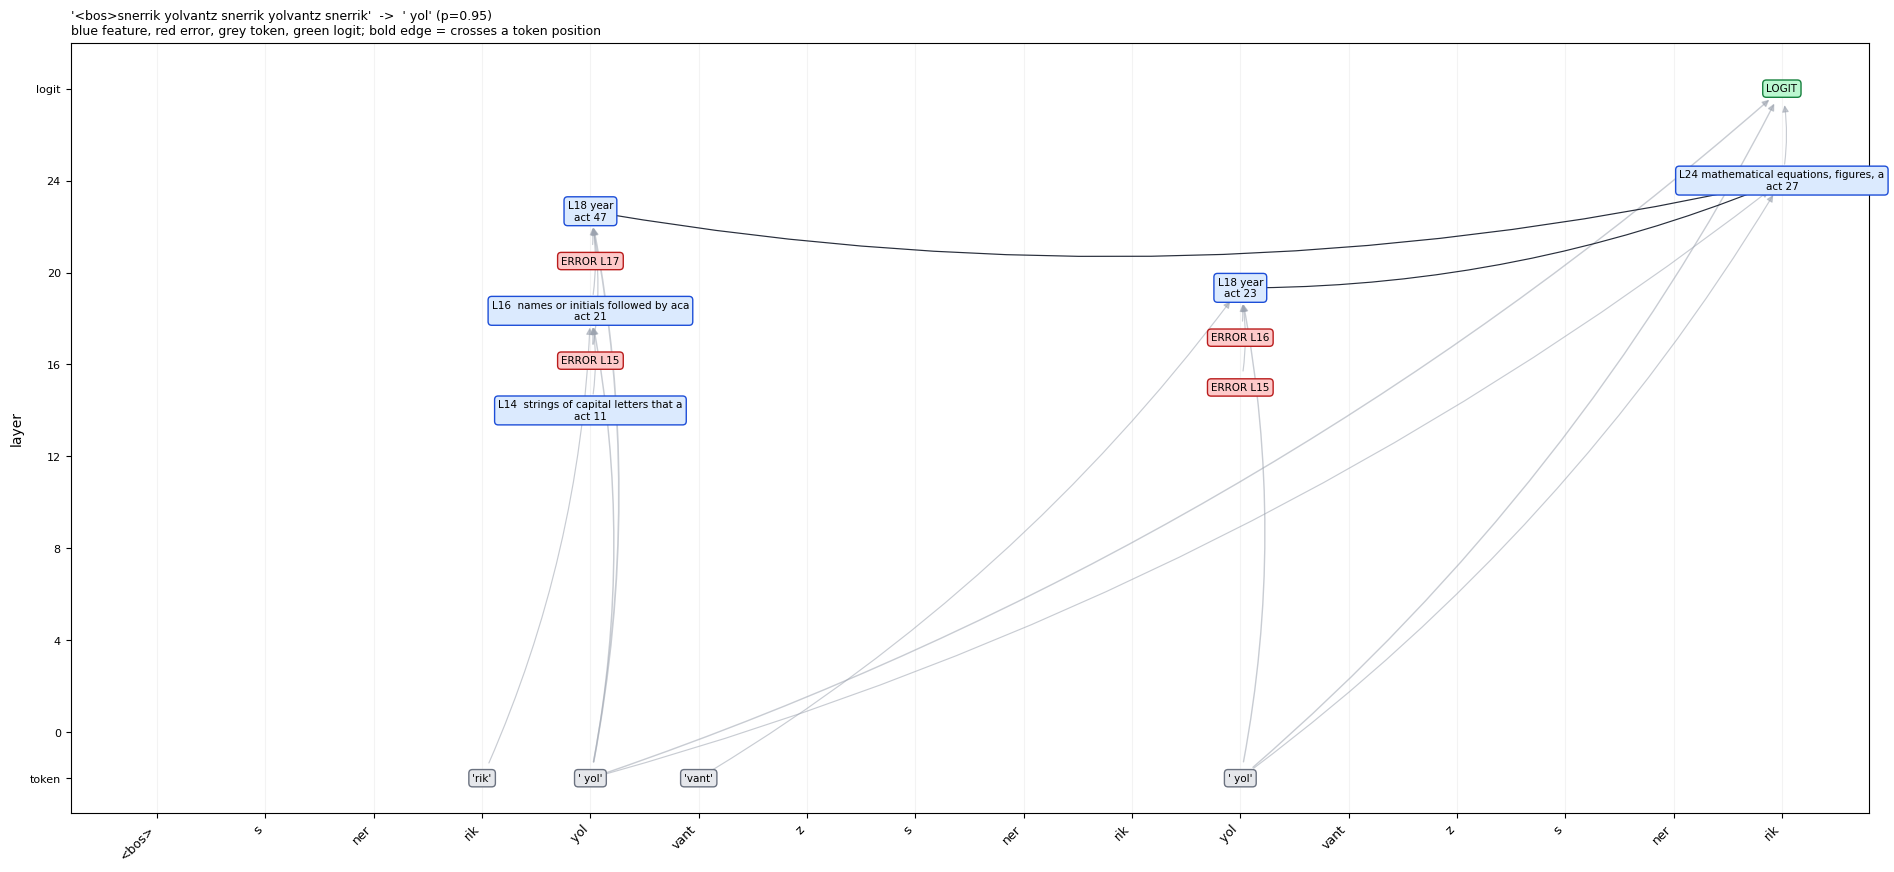

LOGIT ' yol'
  <-  0.056  TOKEN pos4 ' yol'
  <-  0.050  TOKEN pos10 ' yol'
  <-  0.008  L24 pos15('rik') #12059  «mathematical equations, figures, and associated »
      <- *0.017  L18 pos4(' yol') #3315  «year»
          <-  0.107  TOKEN pos4 ' yol'
          <-  0.025  L16 pos4(' yol') #14159  « names or initials followed by academic degree l»
              <-  0.066  TOKEN pos4 ' yol'
              <-  0.021  ERROR L15 pos4(' yol')
              <-  0.015  TOKEN pos3 'rik'
              <-  0.013  L14 pos4(' yol') #3315  « strings of capital letters that are two or fewe»
          <-  0.023  ERROR L17 pos4(' yol')
          <-  0.019  ERROR L15 pos4(' yol')
      <-  0.016  TOKEN pos10 ' yol'
      <- *0.013  L18 pos10(' yol') #3315  «year»
          <-  0.055  TOKEN pos10 ' yol'
          <-  0.016  ERROR L16 pos10(' yol')
          <-  0.014  ERROR L15 pos10(' yol')
          <-  0.012  TOKEN pos5 'vant'
      <-  0.012  TOKEN pos4 ' yol'

* = crosses a token position (2 such edg

In [39]:
practise(2)

In [ ]:
0. no named intermediate feature or 1.  <- *0.017  L18 pos4(' yol') #3315  «year» (cross token posityon) (fed by token pos 4 0.066  TOKEN pos4 ' yol') and into logit (yol)

--- practice 4/5   p0125  [multi_hop] ---
prompt   : '<bos>Someone who grew up in the city of Tokyo would normally speak'
predicts : ' Japanese'  (p=0.24)
token influence  : '<bos>' 0.080, 'Someone' 0.092, ' who' 0.043, ' grew' 0.068, ' up' 0.028, ' in' 0.016, ' the' 0.014, ' city' 0.035, ' of' 0.012, ' Tokyo' 0.051, ' would' 0.033, ' normally' 0.038, ' speak' 0.046
error by position: '<bos>' 0.000, 'Someone' 0.011, ' who' 0.009, ' grew' 0.006, ' up' 0.008, ' in' 0.006, ' the' 0.002, ' city' 0.008, ' of' 0.005, ' Tokyo' 0.027, ' would' 0.011, ' normally' 0.012, ' speak' 0.076
feature influence: early 0.912  mid 0.178  late 0.257   (mid/early 0.20)
peak token influence 'Someone' | peak error ' speak' | read-out position holds 42% of all error



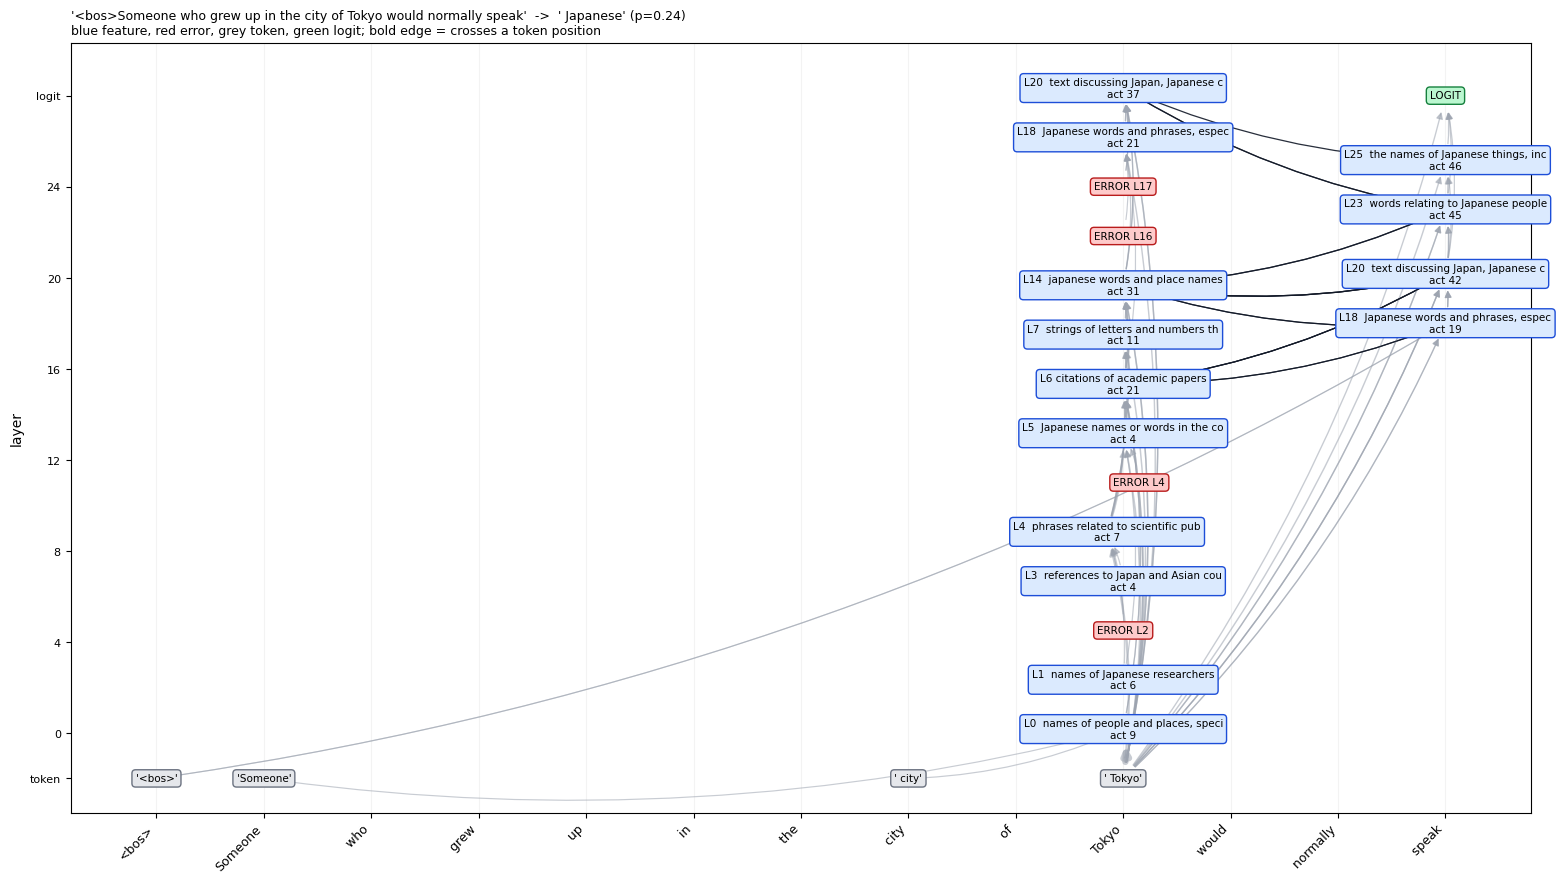

LOGIT ' Japanese'
  <-  0.047  TOKEN pos9 ' Tokyo'
  <-  0.031  L23 pos12(' speak') #850  « words relating to Japanese people, places, and »
      <-  0.049  L20 pos12(' speak') #1194  « text discussing Japan, Japanese culture, or Jap»
          <-  0.039  TOKEN pos9 ' Tokyo'
          <- *0.025  L14 pos9(' Tokyo') #10660  « japanese words and place names»
              <-  0.069  TOKEN pos9 ' Tokyo'
              <-  0.038  L06 pos9(' Tokyo') #10660  «citations of academic papers»
              <-  0.019  L07 pos9(' Tokyo') #13060  « strings of letters and numbers that represent t»
              <-  0.018  L04 pos9(' Tokyo') #10583  « phrases related to scientific publications and »
          <-  0.019  L18 pos12(' speak') #9239  « Japanese words and phrases, especially related »
              <-  0.031  TOKEN pos9 ' Tokyo'
              <- *0.020  L14 pos9(' Tokyo') #10660  « japanese words and place names»   (expanded above)
              <- *0.014  L06 pos9(' Tokyo') #10660  «citat

In [40]:
practise(3)

In [ ]:
Did the job

On the 2 side: cross token, Tokyo crosses to speak to produce ann name dintermediate  (« text discussing Japan, Japanese culture, or Jap») that feeds into  « words relating to Japanese people, places, and »" which feeds into logit

--- practice 5/5   p0217  [obfuscated] ---
prompt   : '<bos>PlEaSe oPeN tHe Front'
predicts : ' d'  (p=0.08)
token influence  : '<bos>' 0.066, 'Pl' 0.056, 'Ea' 0.068, 'Se' 0.037, ' o' 0.027, 'Pe' 0.025, 'N' 0.019, ' t' 0.013, 'He' 0.014, ' Front' 0.022
error by position: '<bos>' 0.000, 'Pl' 0.006, 'Ea' 0.016, 'Se' 0.015, ' o' 0.005, 'Pe' 0.009, 'N' 0.014, ' t' 0.007, 'He' 0.011, ' Front' 0.053
feature influence: early 0.771  mid 0.081  late 0.185   (mid/early 0.10)
peak token influence 'Ea' | peak error ' Front' | read-out position holds 39% of all error



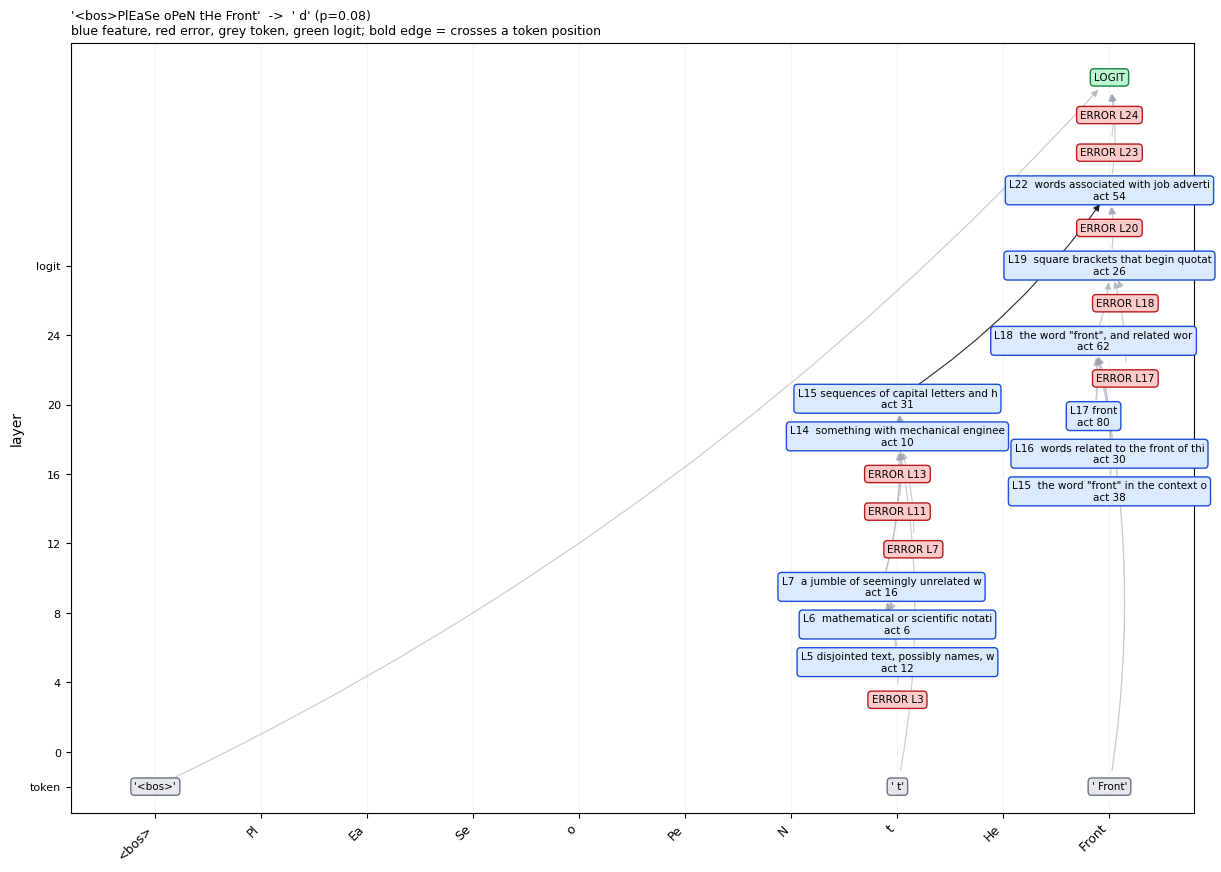

LOGIT ' d'
  <-  0.020  ERROR L24 pos9(' Front')
  <-  0.018  ERROR L23 pos9(' Front')
  <-  0.016  TOKEN pos0 '<bos>'
  <-  0.016  L22 pos9(' Front') #68  « words associated with job advertisements.»
      <-  0.023  L19 pos9(' Front') #13083  « square brackets that begin quotations in legal »
          <-  0.014  ERROR L18 pos9(' Front')
          <-  0.009  ERROR L17 pos9(' Front')
          <-  0.006  L18 pos9(' Front') #9493  « the word "front", and related words, particular»
              <-  0.123  L17 pos9(' Front') #2361  «front»
              <-  0.046  TOKEN pos9 ' Front'
              <-  0.019  L15 pos9(' Front') #2037  « the word "front" in the context of a thing's an»
              <-  0.018  L16 pos9(' Front') #8523  « words related to the front of things»
      <-  0.019  ERROR L20 pos9(' Front')
      <- *0.007  L15 pos7(' t') #6612  «sequences of capital letters and hyphens»
          <-  0.022  ERROR L13 pos7(' t')
          <-  0.015  L07 pos7(' t') #9204  « a jumb

In [41]:
practise(4)

--- practice 1/6   p0153  [code_completion] ---
prompt   : '<bos>if not isinstance(v, str):\n    v = str('
predicts : 'v'  (p=0.98)
token influence  : '<bos>' 0.115, 'if' 0.097, ' not' 0.049, ' isinstance' 0.126, '(' 0.045, 'v' 0.096, ',' 0.018, ' str' 0.042, '):' 0.024, '\n' 0.011, '    ' 0.015, 'v' 0.026, ' =' 0.019, ' str' 0.032, '(' 0.038
error by position: '<bos>' 0.000, 'if' 0.010, ' not' 0.016, ' isinstance' 0.023, '(' 0.012, 'v' 0.028, ',' 0.009, ' str' 0.013, '):' 0.011, '\n' 0.006, '    ' 0.006, 'v' 0.009, ' =' 0.011, ' str' 0.014, '(' 0.065
feature influence: early 1.276  mid 0.254  late 0.476   (mid/early 0.20)
peak token influence ' isinstance' | peak error '(' | read-out position holds 28% of all error



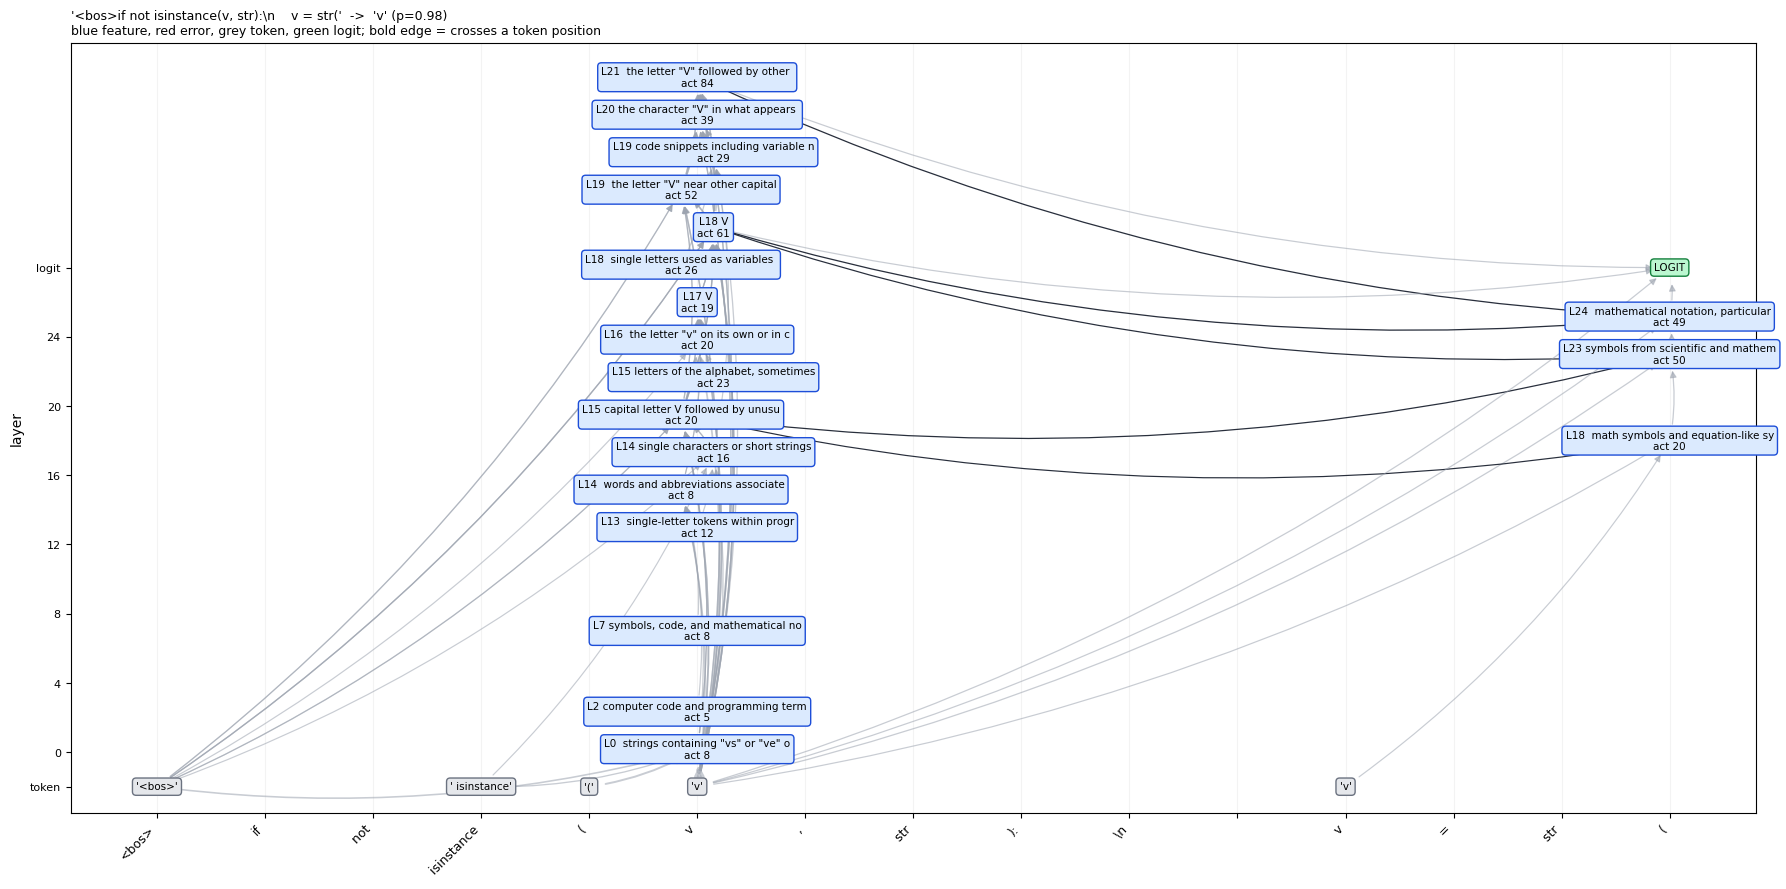

LOGIT 'v'
  <-  0.028  L24 pos14('(') #14077  « mathematical notation, particularly equations w»
      <-  0.035  L23 pos14('(') #404  «symbols from scientific and mathematical notatio»
          <-  0.029  TOKEN pos5 'v'
          <-  0.028  L18 pos14('(') #4609  « math symbols and equation-like syntax»
              <-  0.018  TOKEN pos5 'v'
              <- *0.015  L15 pos5('v') #409  «capital letter V followed by unusual characters,»
              <-  0.014  TOKEN pos11 'v'
          <- *0.023  L15 pos5('v') #409  «capital letter V followed by unusual characters,»   (expanded above)
          <- *0.020  L18 pos5('v') #14512  «V»
              <-  0.097  TOKEN pos5 'v'
              <-  0.033  L15 pos5('v') #409  «capital letter V followed by unusual characters,»   (expanded above)
              <-  0.025  L17 pos5('v') #1213  «V»
              <-  0.023  TOKEN pos0 '<bos>'
      <- *0.028  L18 pos5('v') #14512  «V»   (expanded above)
      <- *0.027  L21 pos5('v') #11902  « the let

In [14]:
practise(0)

In [ ]:
1. named intermediate. tokens at v corss over to produce  «symbols from scientific and mathematical notatio» -> LOGIT. However, the label is vague, no clear association/explanantion of how the model performed the task.

--- practice 2/6   p0126  [code_completion] ---
prompt   : '<bos>def add(a, b):\n    return'
predicts : ' a'  (p=0.95)
token influence  : '<bos>' 0.132, 'def' 0.232, ' add' 0.089, '(' 0.052, 'a' 0.061, ',' 0.016, ' b' 0.023, '):' 0.033, '\n' 0.019, '    ' 0.020, 'return' 0.049
error by position: '<bos>' 0.000, 'def' 0.031, ' add' 0.022, '(' 0.021, 'a' 0.025, ',' 0.010, ' b' 0.013, '):' 0.009, '\n' 0.010, '    ' 0.013, 'return' 0.078
feature influence: early 1.287  mid 0.275  late 0.417   (mid/early 0.21)
peak token influence 'def' | peak error 'return' | read-out position holds 33% of all error



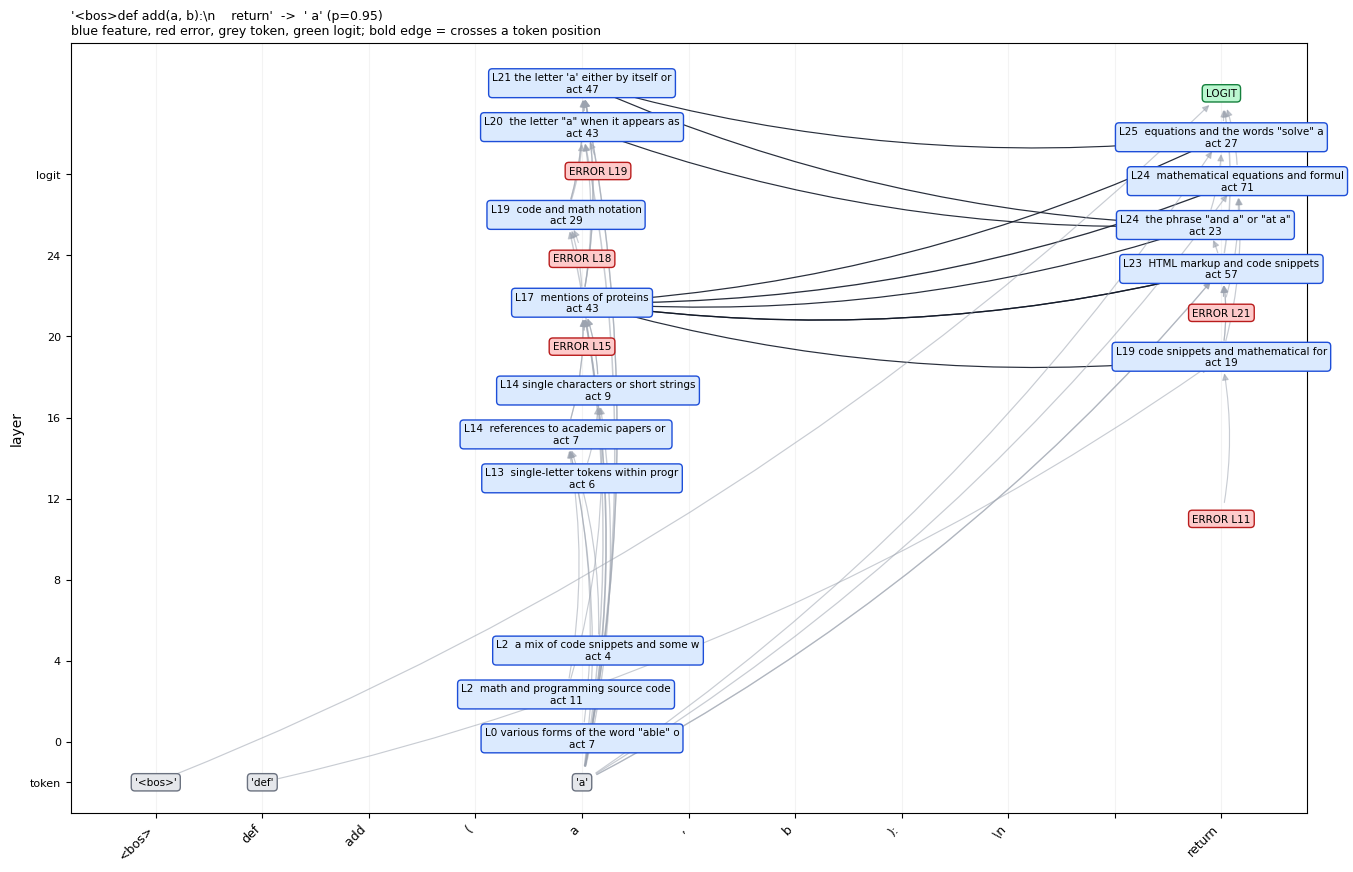

LOGIT ' a'
  <-  0.065  L23 pos10('return') #10991  « HTML markup and code snippets»
      <- *0.032  L17 pos4('a') #8506  « mentions of proteins»
          <-  0.083  TOKEN pos4 'a'
          <-  0.022  ERROR L15 pos4('a')
          <-  0.017  L14 pos4('a') #5558  « references to academic papers or technology»
              <-  0.034  TOKEN pos4 'a'
              <-  0.023  L02 pos4('a') #15600  « a mix of code snippets and some words related t»
              <-  0.016  L02 pos4('a') #9802  « math and programming source code»
              <-  0.014  L00 pos4('a') #4630  «various forms of the word "able" or words contai»
          <-  0.013  L14 pos4('a') #10003  «single characters or short strings frequently us»
              <-  0.044  TOKEN pos4 'a'
              <-  0.013  L13 pos4('a') #4450  « single-letter tokens within programming code»
              <-  0.011  L02 pos4('a') #9802  « math and programming source code»   (expanded above)
      <-  0.026  TOKEN pos4 'a'
      <- 

In [15]:
practise(1)

In [ ]:
2. a 'a' is processed locally before crossing to a feature « mentions of proteins», before being absorbed by a feature " « HTML markup and code snippets»" --> LOGIT('a')

2. checks The trace footer reports at least one
crossing (yes), AND a named feature sits at a non-final position. (yes) After
both pass, the error rule (yes) and the label rule still apply (yes specific and plausible).

--- practice 3/6   p0203  [entity_known_unknown] ---
prompt   : '<bos>Harriet Tubman was born in the year'
predicts : ' '  (p=0.84)
token influence  : '<bos>' 0.116, 'Harriet' 0.118, ' Tub' 0.106, 'man' 0.057, ' was' 0.057, ' born' 0.098, ' in' 0.035, ' the' 0.046, ' year' 0.088
error by position: '<bos>' 0.000, 'Harriet' 0.014, ' Tub' 0.025, 'man' 0.039, ' was' 0.013, ' born' 0.023, ' in' 0.021, ' the' 0.014, ' year' 0.114
feature influence: early 1.307  mid 0.259  late 0.413   (mid/early 0.20)
peak token influence 'Harriet' | peak error ' year' | read-out position holds 44% of all error



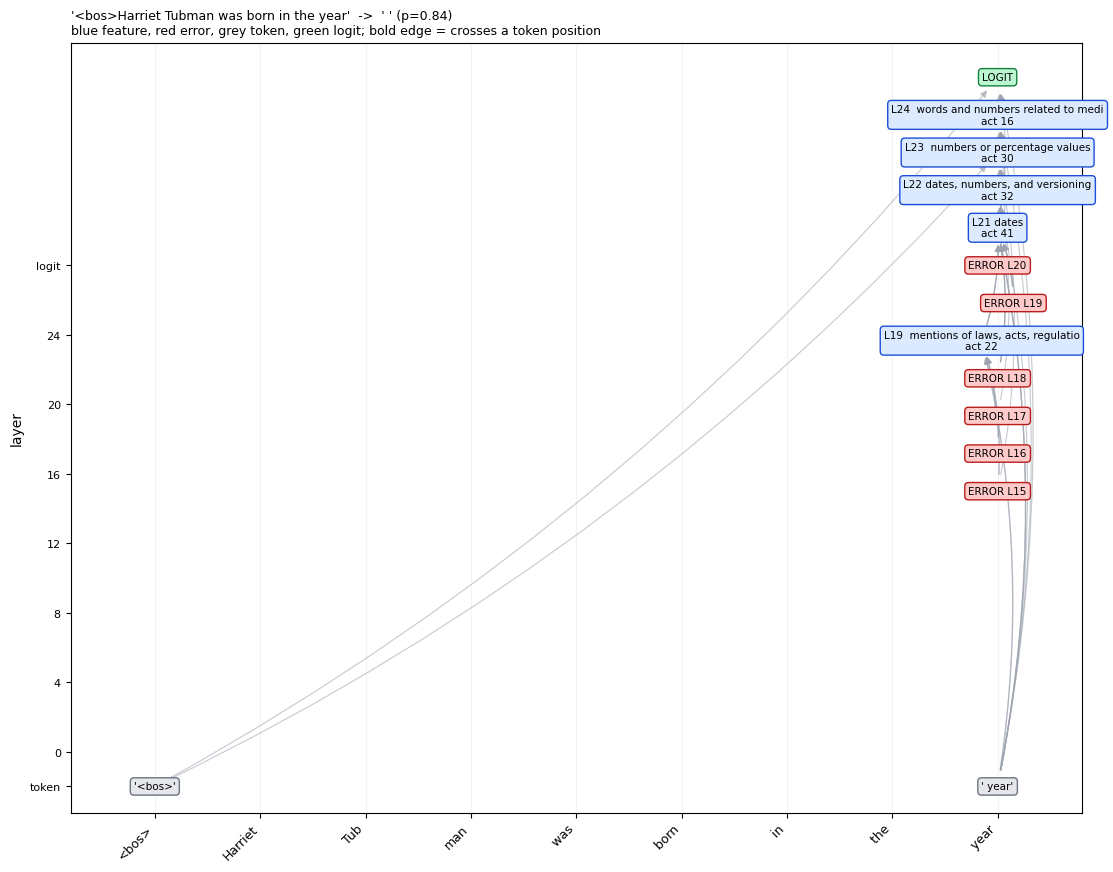

LOGIT ' '
  <-  0.026  L21 pos8(' year') #8799  «dates»
      <-  0.029  L19 pos8(' year') #12916  « mentions of laws, acts, regulations, or policie»
          <-  0.024  TOKEN pos8 ' year'
          <-  0.014  ERROR L15 pos8(' year')
          <-  0.011  ERROR L16 pos8(' year')
      <-  0.026  TOKEN pos8 ' year'
      <-  0.018  ERROR L19 pos8(' year')
      <-  0.016  ERROR L18 pos8(' year')
  <-  0.024  TOKEN pos8 ' year'
  <-  0.018  L24 pos8(' year') #7672  « words and numbers related to medical case studi»
      <-  0.025  L23 pos8(' year') #10271  « numbers or percentage values»
          <-  0.033  L22 pos8(' year') #9157  «dates, numbers, and versioning»
              <-  0.058  L21 pos8(' year') #8799  «dates»   (expanded above)
              <-  0.038  ERROR L20 pos8(' year')
              <-  0.015  ERROR L17 pos8(' year')
              <-  0.015  TOKEN pos8 ' year'
          <-  0.017  L21 pos8(' year') #8799  «dates»   (expanded above)
          <-  0.016  TOKEN pos0 '<b

In [16]:
practise(2)

In [ ]:
0. does not explain the computations that lead to output. No features seem relevant. No crossing over + No real named intermediate -> 0.

--- practice 5/6   p0076  [syntactic_agreement] ---
prompt   : '<bos>Despite everything that had happened earlier that morning, the children in the garden'
predicts : ' were'  (p=0.42)
token influence  : '<bos>' 0.067, 'Despite' 0.088, ' everything' 0.071, ' that' 0.025, ' had' 0.046, ' happened' 0.053, ' earlier' 0.040, ' that' 0.018, ' morning' 0.046, ',' 0.016, ' the' 0.016, ' children' 0.033, ' in' 0.016, ' the' 0.010, ' garden' 0.027
error by position: '<bos>' 0.000, 'Despite' 0.007, ' everything' 0.011, ' that' 0.005, ' had' 0.007, ' happened' 0.011, ' earlier' 0.007, ' that' 0.004, ' morning' 0.013, ',' 0.018, ' the' 0.006, ' children' 0.016, ' in' 0.009, ' the' 0.005, ' garden' 0.045
feature influence: early 0.990  mid 0.170  late 0.185   (mid/early 0.17)
peak token influence 'Despite' | peak error ' garden' | read-out position holds 27% of all error



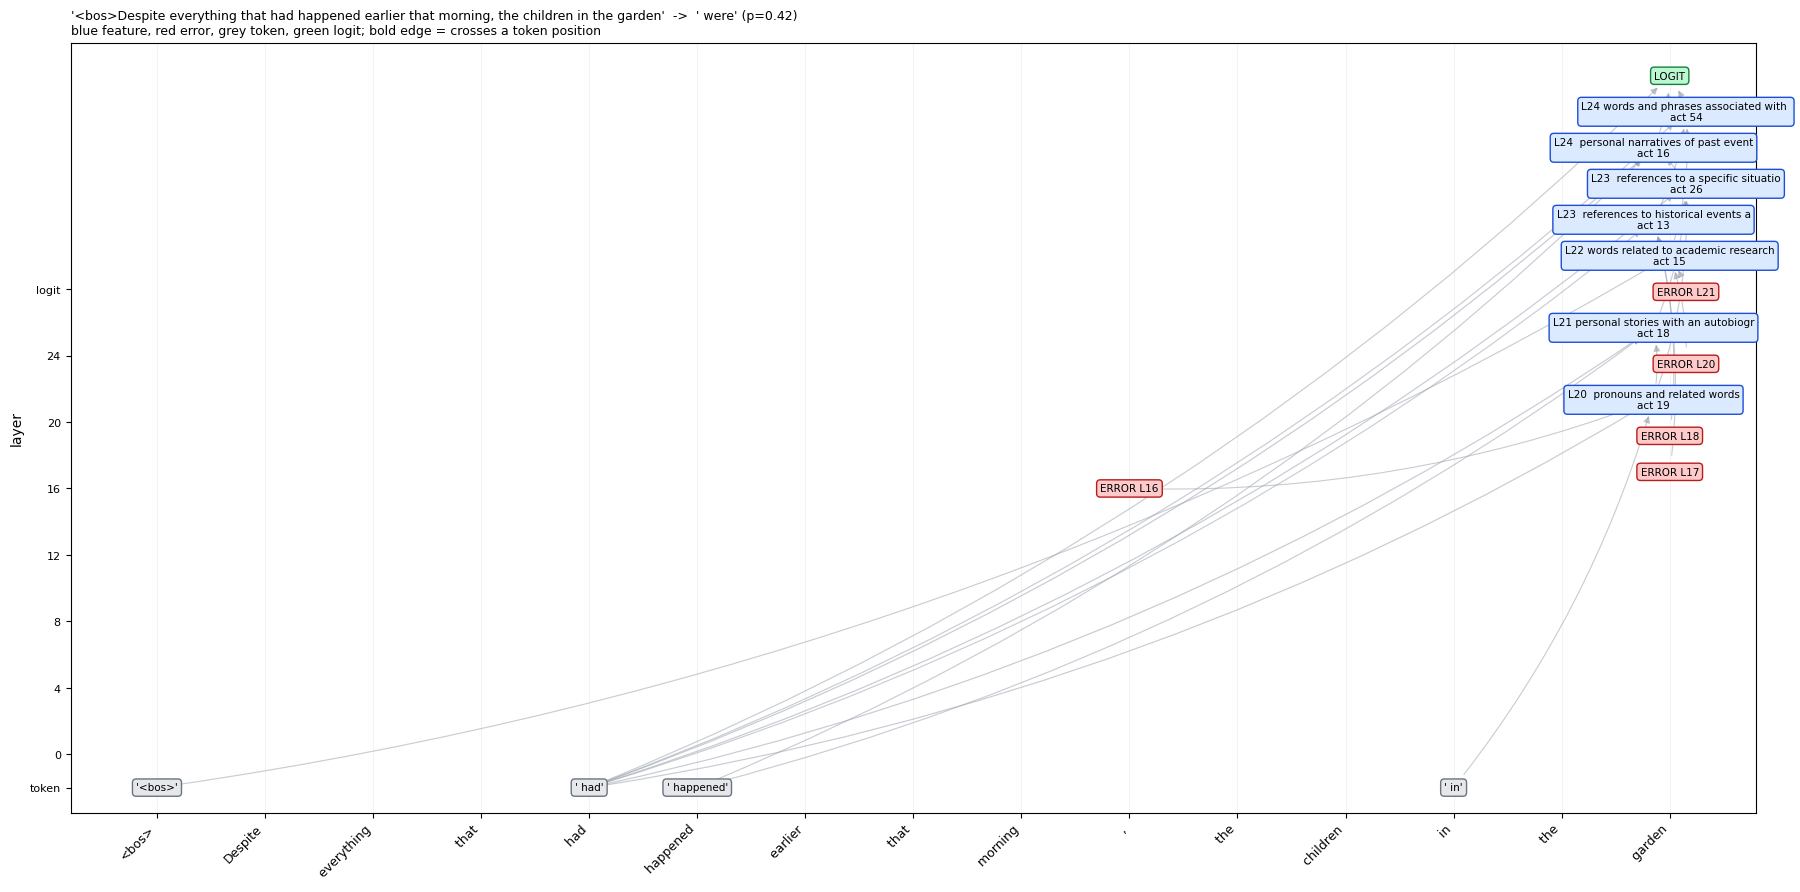

LOGIT ' were'
  <-  0.022  L24 pos14(' garden') #8839  «words and phrases associated with reports, findi»
      <-  0.013  TOKEN pos4 ' had'
      <-  0.012  L22 pos14(' garden') #11517  «words related to academic research»
          <-  0.015  ERROR L21 pos14(' garden')
          <-  0.010  TOKEN pos0 '<bos>'
          <-  0.009  ERROR L20 pos14(' garden')
      <-  0.012  L23 pos14(' garden') #843  « references to historical events and situations,»
          <-  0.010  TOKEN pos4 ' had'
          <-  0.007  ERROR L18 pos14(' garden')
          <-  0.007  ERROR L17 pos14(' garden')
  <-  0.014  TOKEN pos4 ' had'
  <-  0.011  L24 pos14(' garden') #1355  « personal narratives of past events and argument»
      <-  0.024  TOKEN pos4 ' had'
      <-  0.014  TOKEN pos5 ' happened'
      <-  0.013  L23 pos14(' garden') #1993  « references to a specific situation, and how the»
          <-  0.021  TOKEN pos4 ' had'
          <-  0.012  L20 pos14(' garden') #12650  « pronouns and related word

In [17]:
practise(4)

In [ ]:
0. No crossing but               <-  0.008  L20 pos14(' garden') #12650  « pronouns and related words»   (expanded above)
--->
          <-  0.007  L21 pos14(' garden') #1898  «personal stories with an autobiographical tone: »
--->      <-  0.013  L23 pos14(' garden') #1993  « references to a specific situation, and how the»
no real plausible name intermediate (garden doesn't make sense for how it computed were)

--- practice 4/6   p0194  [entity_known_unknown] ---
prompt   : '<bos>Kathleen Corbell was born in the year'
predicts : ' '  (p=0.84)
token influence  : '<bos>' 0.114, 'Kathleen' 0.092, ' Cor' 0.054, 'bell' 0.060, ' was' 0.070, ' born' 0.127, ' in' 0.044, ' the' 0.061, ' year' 0.108
error by position: '<bos>' 0.000, 'Kathleen' 0.015, ' Cor' 0.006, 'bell' 0.023, ' was' 0.014, ' born' 0.026, ' in' 0.014, ' the' 0.014, ' year' 0.126
feature influence: early 1.246  mid 0.238  late 0.475   (mid/early 0.19)
peak token influence ' born' | peak error ' year' | read-out position holds 53% of all error



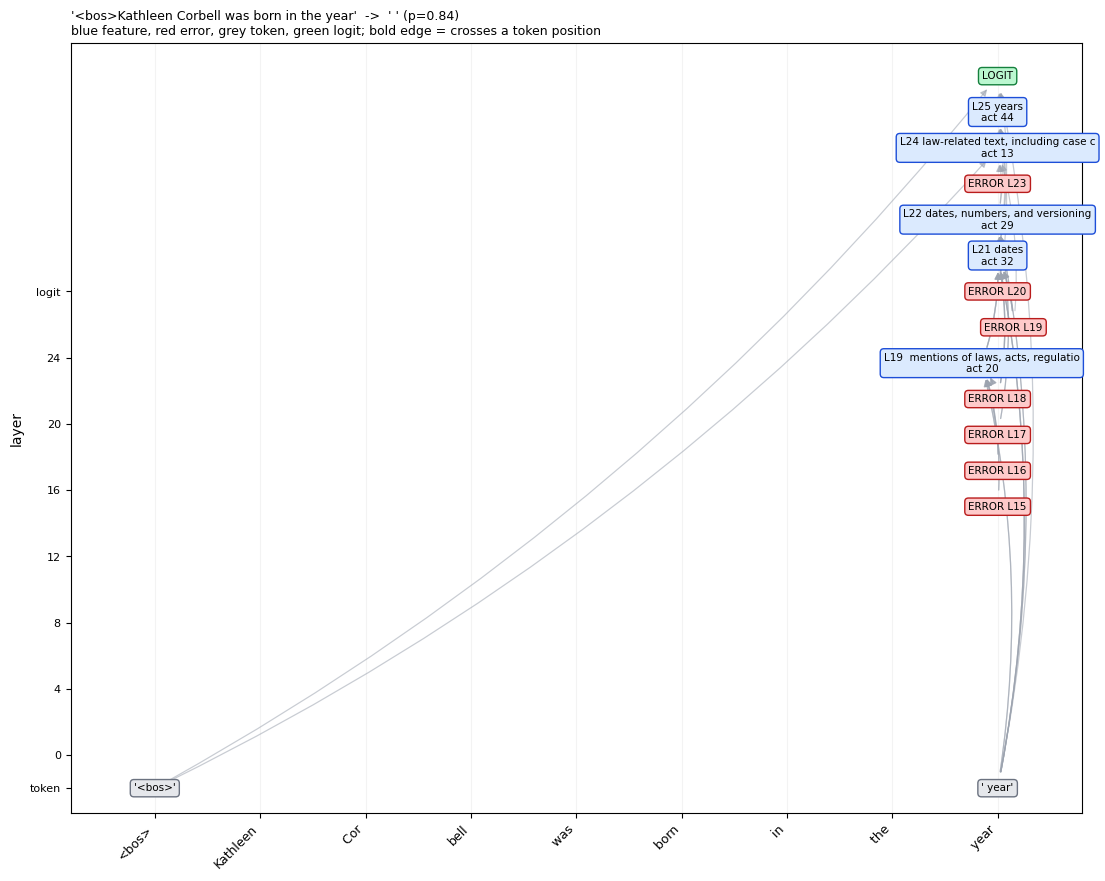

LOGIT ' '
  <-  0.061  L25 pos8(' year') #1460  «years»
      <-  0.036  L21 pos8(' year') #8799  «dates»
          <-  0.036  ERROR L18 pos8(' year')
          <-  0.031  ERROR L19 pos8(' year')
          <-  0.031  L19 pos8(' year') #12916  « mentions of laws, acts, regulations, or policie»
              <-  0.031  ERROR L18 pos8(' year')
              <-  0.025  TOKEN pos8 ' year'
              <-  0.019  ERROR L15 pos8(' year')
              <-  0.013  ERROR L16 pos8(' year')
          <-  0.029  TOKEN pos8 ' year'
      <-  0.025  L22 pos8(' year') #9157  «dates, numbers, and versioning»
          <-  0.057  L21 pos8(' year') #8799  «dates»   (expanded above)
          <-  0.034  ERROR L20 pos8(' year')
          <-  0.021  ERROR L17 pos8(' year')
          <-  0.018  TOKEN pos8 ' year'
      <-  0.025  ERROR L20 pos8(' year')
      <-  0.021  L24 pos8(' year') #523  «law-related text, including case citations, lega»
          <-  0.026  ERROR L23 pos8(' year')
          <-  0.022

In [18]:
practise(3)

In [ ]:
1. Local processing of legible "date" feature «dates, numbers, and versioning»  - > dates -> "years" _> LOGIT

--- practice 6/6   p0073  [syntactic_agreement] ---
prompt   : '<bos>Despite everything that had happened earlier that morning, the book on the shelves'
predicts : ' was'  (p=0.16)
token influence  : '<bos>' 0.063, 'Despite' 0.074, ' everything' 0.058, ' that' 0.021, ' had' 0.033, ' happened' 0.043, ' earlier' 0.033, ' that' 0.016, ' morning' 0.039, ',' 0.017, ' the' 0.016, ' book' 0.030, ' on' 0.016, ' the' 0.012, ' shelves' 0.038
error by position: '<bos>' 0.000, 'Despite' 0.006, ' everything' 0.009, ' that' 0.004, ' had' 0.006, ' happened' 0.009, ' earlier' 0.005, ' that' 0.004, ' morning' 0.011, ',' 0.015, ' the' 0.006, ' book' 0.010, ' on' 0.007, ' the' 0.005, ' shelves' 0.046
feature influence: early 0.856  mid 0.144  late 0.128   (mid/early 0.17)
peak token influence 'Despite' | peak error ' shelves' | read-out position holds 32% of all error



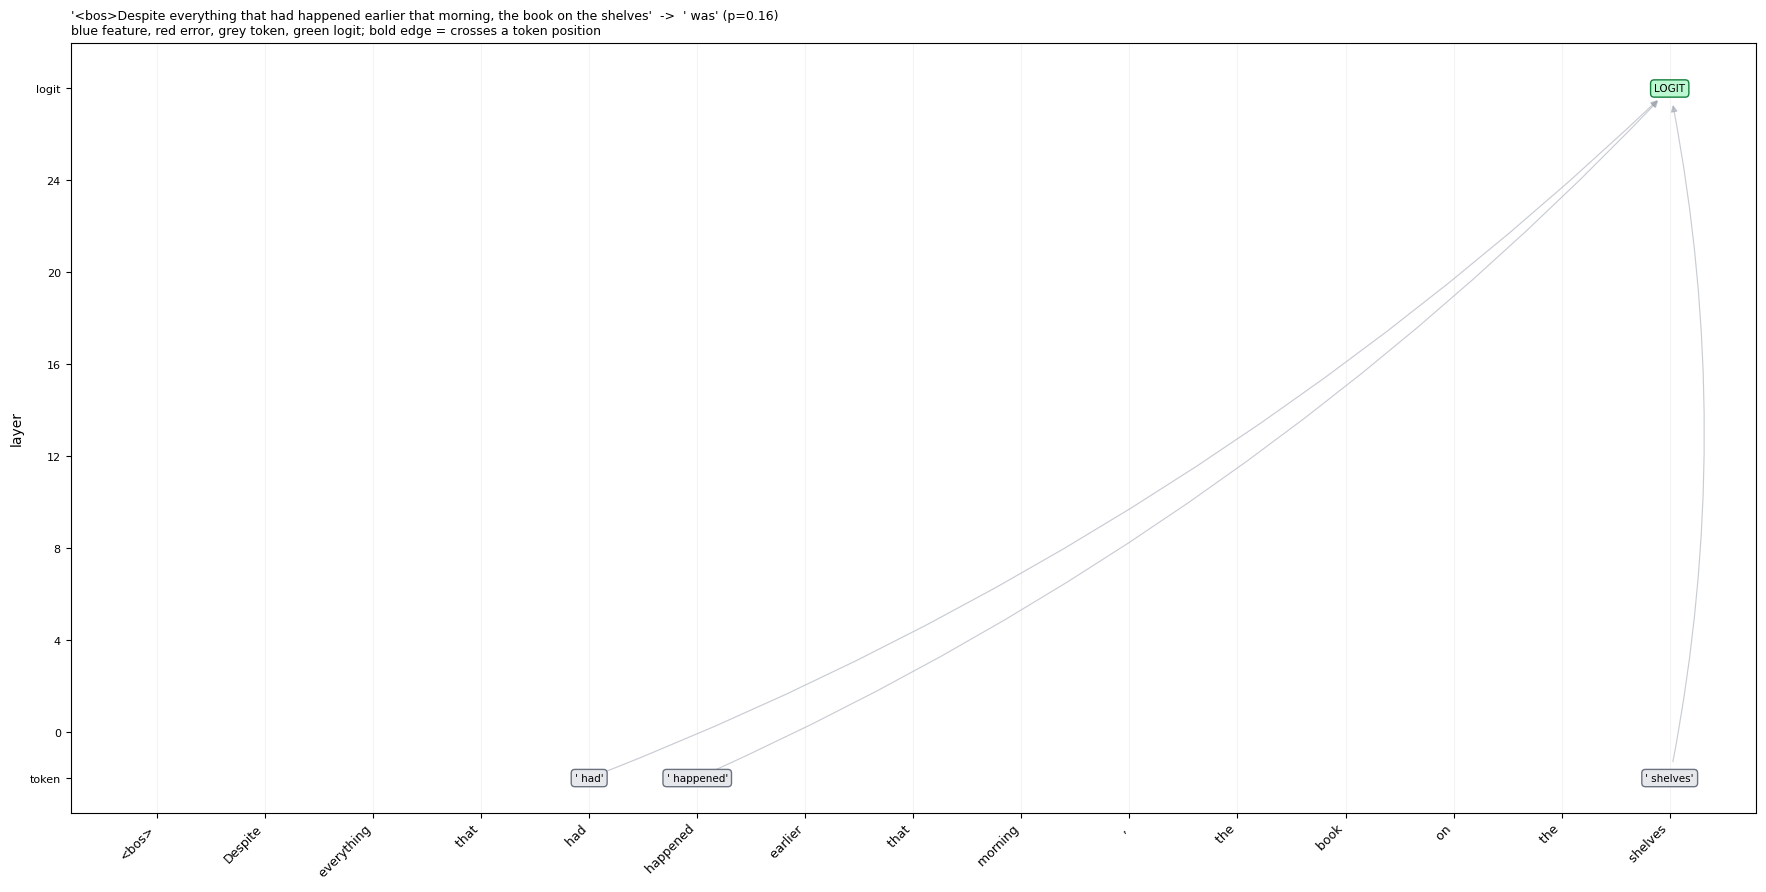

LOGIT ' was'
  <-  0.016  TOKEN pos4 ' had'
  <-  0.011  TOKEN pos14 ' shelves'
  <-  0.010  TOKEN pos5 ' happened'

* = crosses a token position (0 such edges drawn)

47 of the drawn features have a Neuronpedia description.


In [20]:
practise(5)

In [ ]:
0.  No cross-position edge AND no named intermediate; 

--- practice 1/6   p0153  [code_completion] ---
prompt   : '<bos>if not isinstance(v, str):\n    v = str('
predicts : 'v'  (p=0.98)
token influence  : '<bos>' 0.115, 'if' 0.097, ' not' 0.049, ' isinstance' 0.126, '(' 0.045, 'v' 0.096, ',' 0.018, ' str' 0.042, '):' 0.024, '\n' 0.011, '    ' 0.015, 'v' 0.026, ' =' 0.019, ' str' 0.032, '(' 0.038
error by position: '<bos>' 0.000, 'if' 0.010, ' not' 0.016, ' isinstance' 0.023, '(' 0.012, 'v' 0.027, ',' 0.009, ' str' 0.013, '):' 0.011, '\n' 0.006, '    ' 0.006, 'v' 0.009, ' =' 0.011, ' str' 0.014, '(' 0.065
feature influence: early 1.276  mid 0.254  late 0.476   (mid/early 0.20)
peak token influence ' isinstance' | peak error '(' | read-out position holds 28% of all error



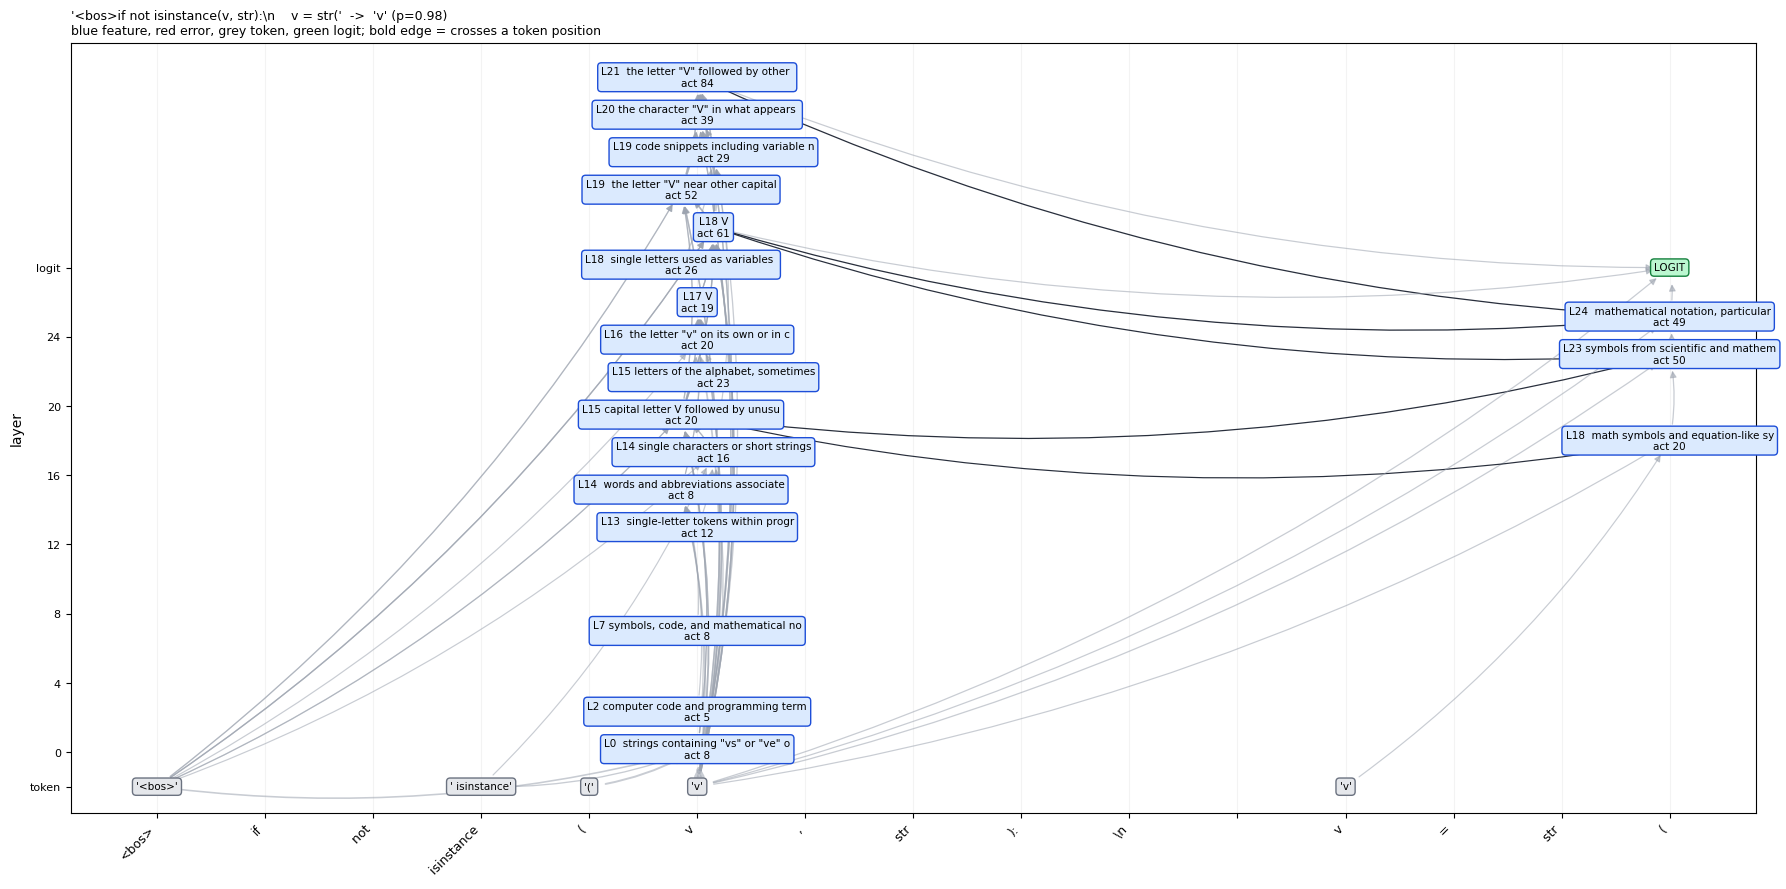

LOGIT 'v'
  <-  0.028  L24 pos14('(') #14077  « mathematical notation, particularly equations w»
      <-  0.035  L23 pos14('(') #404  «symbols from scientific and mathematical notatio»
          <-  0.029  TOKEN pos5 'v'
          <-  0.028  L18 pos14('(') #4609  « math symbols and equation-like syntax»
              <-  0.018  TOKEN pos5 'v'
              <- *0.015  L15 pos5('v') #409  «capital letter V followed by unusual characters,»
              <-  0.014  TOKEN pos11 'v'
          <- *0.023  L15 pos5('v') #409  «capital letter V followed by unusual characters,»   (expanded above)
          <- *0.020  L18 pos5('v') #14512  «V»
              <-  0.097  TOKEN pos5 'v'
              <-  0.033  L15 pos5('v') #409  «capital letter V followed by unusual characters,»   (expanded above)
              <-  0.025  L17 pos5('v') #1213  «V»
              <-  0.023  TOKEN pos0 '<bos>'
      <- *0.028  L18 pos5('v') #14512  «V»   (expanded above)
      <- *0.027  L21 pos5('v') #11902  « the let

In [21]:
practise(0)

## Part 6 — Calibration

Write these in your own words before rating, and keep them visible.

In [ ]:
CALIB = f"{OUT}/calibration.json"
if os.path.exists(CALIB):
    CALIBRATION = json.load(open(CALIB))
    print("existing calibration reused")
else:
    CALIBRATION = {
        "2": ("an interpretable intermediate feature built at a CONTENT position, saying something "
              "the prompt does not, carried by a cross-position edge into a read-out-position "
              "feature that feeds the logit"),
        "1": ("a named feature I can read but no path to the logit; OR a complete path whose "
              "intermediate I cannot name (vague or implausible label - record it); OR a real "
              "named intermediate sitting only at the read-out position, no crossing"),
        "0": ("no cross-position edge AND no named intermediate; OR the feature the explanation "
              "depends on has an error node as its largest input; OR the explanation restates the "
              "prompt (a token repeated, a space before a year, an article expected)"),
        "check_before_2": "trace footer reports >=1 crossing AND a named feature at a non-final position",
        "error_rule": ("unreadable when an error node is its largest input, or most of its inputs; "
                       "error elsewhere in the tree does not disqualify"),
        "influence_rule": ("magnitude is not part of the rating; chains weaker than the direct "
                           "token-to-logit edge are flagged in the reason"),
        "label_rule": ("a label counts as naming only if specific and plausible for its position; "
                       "a label containing the predicted word is not an intermediate unless "
                       "something upstream produced it"),
        "naming_rule": "strict: a 2 requires naming the intermediate from its Neuronpedia description",
        "viewer": f"explain(): summary, labelled path diagram, trace. depth={DEPTH}, width={WIDTH}, "
                  f"min_w={MIN_W}, keep_min={KEEP_MIN}",
        "labels": "Neuronpedia gemma-2-2b/{layer}-gemmascope-transcoder-16k",
        "worked_examples": {
            "2": "Omaha -> «US states and geographical terms» (pos11) -> crosses -> «Nebraska and Omaha» (pos12) -> logit",
            "1": "'heavy' -> «negative experiences, often described as burden» - real feature, no crossing, all at read-out",
            "0": "induction: logit fed by two raw token embeddings and an error node; moved, nothing computed",
        },
    }
    json.dump(CALIBRATION, open(CALIB, "w"), indent=2)
print(json.dumps(CALIBRATION, indent=2)[:1400])

### Consistency rehearsal

Re-run practice graph 1 and rate it from memory. A different number than earlier means the criteria are not yet stable.

In [ ]:
practise(0)

## Part 7 — Rating machinery

`show()` displays the next unrated presentation; `record(rating, "reason")` saves it. **The reason
is mandatory** (≥ 20 characters) — it is what stream 3 audits, and it is worth recording anyway.

The exact text shown is stored once per presentation in `graph_texts.jsonl`, which is what
streams 2 and 3 consume.

In [9]:
RATINGS = f"{OUT}/ratings_{RATER_ID}.jsonl"
TEXTS   = f"{OUT}/graph_texts.jsonl"
_current = {}

def _texts():
    p = TEXTS if os.path.exists(TEXTS) else find_input("graph_texts.jsonl", required=False)
    if not p:
        return {}
    return {json.loads(l)["presentation"]: json.loads(l) for l in open(p) if l.strip()}

def rated():
    if not os.path.exists(RATINGS):
        return set()
    return {json.loads(l)["presentation"] for l in open(RATINGS) if l.strip()}

def show(n=None):
    global _current
    done = rated()
    if n is None:
        left = [p for p in manifest.presentation if p not in done]
        if not left:
            print("all rated - go to Part 9"); return
        n = int(left[0])
    row = manifest[manifest.presentation == n].iloc[0]
    _current = dict(presentation=int(n), prompt_id=row.prompt_id, t0=time.time())
    print(f"=== presentation {n} of {len(manifest)}   ({len(done)} rated by {RATER_ID}) ===")

    store = _texts()
    g = attribute(prompt=row.prompt, model=model, **AK)
    out = explain(g, model, NL, depth=DEPTH, width=WIDTH, min_w=MIN_W, keep_min=KEEP_MIN)
    del g; free()
    _current["text"] = out["text"]
    if n not in store:
        with open(TEXTS, "a") as f:
            f.write(json.dumps({"presentation": int(n), "prompt_id": row.prompt_id,
                                "category": row.category, "text": out["text"]}) + "\n")
    print("\n2 = named intermediate on a complete path | 1 = feature, no path | 0 = neither")
    print('record(rating, "your reason")')

def record(rating, reason=""):
    assert rating in (0, 1, 2), "rating must be 0, 1 or 2"
    assert _current, "call show() first"
    assert len(reason.strip()) >= 20, \
        "state your reasoning (>=20 chars): name the chain, or say why there isn't one"
    secs = time.time() - _current["t0"]
    if secs > 300:
        print(f"note: {secs/60:.1f} min, over the 5-minute cap")
    rec = dict(presentation=_current["presentation"], prompt_id=_current["prompt_id"],
               rater=RATER_ID, modality=MODALITY, rating=int(rating), reason=reason.strip(),
               seconds=round(secs, 1),
               at=datetime.datetime.now().isoformat(timespec="seconds"))
    with open(RATINGS, "a") as f:
        f.write(json.dumps(rec) + "\n"); f.flush(); os.fsync(f.fileno())
    print(f"recorded {rating} ({secs:.0f}s). {len(rated())}/{len(manifest)} done. show() for next.")

print(f"{len(rated())}/{len(manifest)} already rated by {RATER_ID}. Run show() to begin.")

0/50 already rated by js. Run show() to begin.


## Part 8 — Rate

Work 1 to 50 in order. Don't try to spot the duplicates; don't revise earlier ratings.

In [ ]:
show()

In [ ]:
# record(1, "")

## Part 9 — Completeness check

Run before any LLM stream. Streams 2 and 3 must not run while stream 1 is incomplete.

In [ ]:
h1 = pd.DataFrame([json.loads(l) for l in open(f"{OUT}/ratings_js.jsonl")]) \
     if os.path.exists(f"{OUT}/ratings_js.jsonl") else pd.DataFrame()
print(f"stream 1: {len(h1)}/{len(manifest)} rated")
texts = _texts()
print(f"stored texts: {len(texts)}/{len(manifest)}")
STREAM1_DONE = len(h1) == len(manifest) and len(texts) == len(manifest)
print("ready for streams 2 and 3:", STREAM1_DONE)

## Part 10 — Stream 2: independent LLM rater (exploratory)

Run through a chat interface, not the API. Presentations are shuffled with a fixed seed and written
to batch files of ten; the rubric is repeated in full at the head of each batch.

**No duplicate pair shares a batch.** A duplicate landing in the same context window as its twin
could be recognised as a repeat, which the human rater cannot do — that would make the LLM's
duplicate consistency meaningless. The splitter below enforces the separation and reports any swap
it had to make.

In [ ]:
assert STREAM1_DONE, "stream 1 must be complete first (D3.11)"
LLM_MODEL = "chat-interface"          # record the model you actually paste into
BATCH = 10

RUBRIC = """You rate attribution graphs of a language model, shown as text.

2 = a causal path from input tokens to the output can be stated in one sentence, naming the
    intermediate features
1 = at least one meaningful intermediate feature is identifiable, but no complete path
0 = neither

Clarifications the human rater is using:
- a 2 requires BOTH at least one cross-position edge (the trace footer counts them) AND a named
  intermediate feature at a non-final token position
- a feature is unreadable when an error node is its largest input
- magnitude is not part of the rating
- a label counts as naming only if specific and plausible for its position; a label that merely
  contains the predicted word is not an intermediate unless something upstream produced it
- an explanation that restates the prompt (a token repeated, a space before a year, an article
  expected) is a 0"""

order = sorted(texts)
random.Random(0).shuffle(order)

# --- separate duplicate pairs across batches ---------------------------------
pid_of = {n: texts[n]["prompt_id"] for n in order}
swaps = []
def batch_of(i): return i // BATCH

for i, n in enumerate(order):
    for j in range(i + 1, min((batch_of(i) + 1) * BATCH, len(order))):
        if pid_of[order[j]] != pid_of[n]:
            continue
        # order[j] is a duplicate of order[i] inside the same batch: swap it out
        for k in range(len(order)):
            if batch_of(k) == batch_of(j):
                continue
            cand = order[k]
            if pid_of[cand] in {pid_of[order[m]] for m in
                                range(batch_of(j) * BATCH, min((batch_of(j) + 1) * BATCH, len(order)))}:
                continue
            if pid_of[order[j]] in {pid_of[order[m]] for m in
                                    range(batch_of(k) * BATCH, min((batch_of(k) + 1) * BATCH, len(order)))}:
                continue
            order[j], order[k] = order[k], order[j]
            swaps.append((int(n), int(order[k]), batch_of(j) + 1, batch_of(k) + 1))
            break
        break

# verify
bad = []
for b in range(0, len(order), BATCH):
    pids = [pid_of[n] for n in order[b:b + BATCH]]
    dupes = {p for p in pids if pids.count(p) > 1}
    if dupes:
        bad.append((b // BATCH + 1, dupes))
print(f"{len(swaps)} swap(s) made to separate duplicate pairs: {swaps}")
print("batches still containing a duplicate pair:", bad or "none")
assert not bad, "could not separate all duplicate pairs - widen BATCH or reshuffle"

BATCH_DIR = f"{OUT}/llm_batches"
os.makedirs(BATCH_DIR, exist_ok=True)
for b in range(0, len(order), BATCH):
    batch = order[b:b + BATCH]
    with open(f"{BATCH_DIR}/rate_batch_{b//BATCH + 1}.txt", "w") as f:
        f.write(RUBRIC + "\n\n")
        f.write("Rate each graph below. Reply with a JSON array only, nothing else:\n")
        f.write('[{"presentation": N, "rating": 0, "reason": "<one sentence>"}, ...]\n\n')
        for n in batch:
            f.write(f"===== PRESENTATION {n} =====\n{texts[n]['text']}\n\n")
json.dump({"order": [int(n) for n in order], "batch": BATCH,
           "swaps": swaps, "model": LLM_MODEL},
          open(f"{OUT}/llm_batch_plan.json", "w"), indent=2)
print(f"\nwrote {len(order)//BATCH + (len(order) % BATCH > 0)} batch files to {BATCH_DIR}")
print("paste each file into a FRESH chat, save the reply as reply_rate_<n>.json in the same folder")

In [ ]:
# read the chat replies back
recs = []
for path in sorted(glob.glob(f"{OUT}/llm_batches/reply_rate_*.json")):
    for d in json.load(open(path)):
        n = int(d["presentation"])
        recs.append(dict(presentation=n, prompt_id=texts[n]["prompt_id"], rater="llm",
                         modality="text_only", rating=int(d["rating"]),
                         reason=d.get("reason", ""), model=LLM_MODEL))
assert recs, "no reply files found - save chat replies as reply_rate_<n>.json"
seen = {r["presentation"] for r in recs}
missing = sorted(set(texts) - seen)
print(f"{len(recs)} LLM ratings loaded; missing: {missing or 'none'}")
with open(f"{OUT}/ratings_llm.jsonl", "w") as f:
    for r in recs:
        f.write(json.dumps(r) + "\n")

## Part 11 — Stream 3: audit of stream 1's reasoning (exploratory)

Same delivery. The judge receives the stored text, the rubric, and stream 1's rating and stated
reason, and answers two questions separately: does the **reason** follow from the graph, and does
the **rating** follow from the reason. The second rate — *defensible rating, unsupported reason* —
is the one worth reporting.

In [ ]:
assert STREAM1_DONE, "stream 1 must be complete first (D3.11)"
AUDIT_SYS = RUBRIC + """

You are auditing a human rating, not replacing it. For each item answer separately:
  reason_supported : does the stated reason follow from the graph text?
  rating_follows   : given the stated reason, does the rating follow from the rubric?
Reply with a JSON array only, nothing else:
[{"presentation": N, "reason_supported": true, "rating_follows": true,
  "your_rating": 0, "comment": "<one sentence>"}, ...]"""

h1i = h1.set_index("presentation")
for b in range(0, len(order), BATCH):
    batch = [n for n in order[b:b + BATCH] if n in h1i.index]
    with open(f"{OUT}/llm_batches/audit_batch_{b//BATCH + 1}.txt", "w") as f:
        f.write(AUDIT_SYS + "\n\n")
        for n in batch:
            row = h1i.loc[n]
            f.write(f"===== PRESENTATION {n} =====\n{texts[n]['text']}\n\n"
                    f"HUMAN RATING: {int(row.rating)}\nHUMAN REASON: {row.reason}\n\n")
print(f"wrote audit batches to {OUT}/llm_batches")
print("paste each into a FRESH chat, save replies as reply_audit_<n>.json")

In [ ]:
# read the audit replies back
arecs = []
for path in sorted(glob.glob(f"{OUT}/llm_batches/reply_audit_*.json")):
    for d in json.load(open(path)):
        n = int(d["presentation"])
        arecs.append(dict(presentation=n, prompt_id=texts[n]["prompt_id"],
                          human_rating=int(h1i.loc[n].rating), model=LLM_MODEL,
                          reason_supported=bool(d["reason_supported"]),
                          rating_follows=bool(d["rating_follows"]),
                          your_rating=int(d["your_rating"]), comment=d.get("comment", "")))
if arecs:
    with open(f"{OUT}/audit_llm.jsonl", "w") as f:
        for r in arecs:
            f.write(json.dumps(r) + "\n")
print(f"{len(arecs)} audit records loaded")

## Part 12 — Unblind and compare

Only once stream 1 is complete. This is where metrics appear.

In [ ]:
def quadratic_kappa(x, y, k=3):
    # quadratic weights: disagreeing by 2 counts 4x worse than disagreeing by 1
    x, y = np.asarray(x, int), np.asarray(y, int)
    n = len(x)
    O = np.zeros((k, k))
    for i, j in zip(x, y):
        O[i, j] += 1
    W = np.array([[(i - j) ** 2 / (k - 1) ** 2 for j in range(k)] for i in range(k)])
    E = np.outer(np.bincount(x, minlength=k), np.bincount(y, minlength=k)) / n
    den = (W * E).sum()
    return float(1 - (W * O).sum() / den) if den > 0 else float("nan")

def load(path):
    return pd.DataFrame([json.loads(l) for l in open(path)]) if os.path.exists(path) else None

streams = {}
for rid in ["js", "llm"]:
    p = f"{OUT}/ratings_{rid}.jsonl"
    d = load(p)
    if d is not None and len(d):
        streams[rid] = d.dropna(subset=["rating"])
print("streams present:", {k: len(v) for k, v in streams.items()})

# intra-rater consistency on the 10 duplicates, per stream
for rid, d in streams.items():
    dup = d.groupby("prompt_id").filter(lambda x: len(x) == 2)
    pr = dup.sort_values("presentation").groupby("prompt_id").rating.apply(list)
    if len(pr):
        a = [p[0] for p in pr]; b = [p[1] for p in pr]
        print(f"{rid:7s} duplicates n={len(a)}  exact {np.mean(np.array(a)==np.array(b)):.0%}  "
              f"kappa {quadratic_kappa(a, b):.3f}")

In [ ]:
# between-stream agreement, on first presentations only
firsts = {rid: d.sort_values("presentation").drop_duplicates("prompt_id").set_index("prompt_id").rating
          for rid, d in streams.items()}
keys = list(firsts)
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        a, b = firsts[keys[i]].align(firsts[keys[j]], join="inner")
        print(f"{keys[i]} vs {keys[j]}: n={len(a)}  exact {np.mean(a.values==b.values):.0%}  "
              f"kappa {quadratic_kappa(a.values, b.values):.3f}")

In [ ]:
from scipy.stats import spearmanr
res = pd.read_csv(find_input("results.csv"), keep_default_na=False)
res["replacement_score"] = res.replacement_score.astype(float)

rows = []
for rid, s in firsts.items():
    j = s.rename("rating").reset_index().merge(
        res[["prompt_id", "replacement_score", "completeness_score", "err_pos_gini_norm",
             "err_final_share", "category"]], on="prompt_id")
    rho, p = spearmanr(j.replacement_score, j.rating)
    rows.append(dict(stream=rid, n=len(j), rho=round(float(rho), 3), p=round(float(p), 4)))
    if rid == "js":
        J = j
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nP5 (stream 1): rho={rows[0]['rho']:+.3f} -> "
      f"{'HOLDS' if abs(rows[0]['rho']) < 0.4 else 'FAILS'} the |rho| < 0.4 prediction")
print()
print(J.groupby("rating").agg(n=("rating", "size"),
                              mean_replacement=("replacement_score", "mean"),
                              mean_gini=("err_pos_gini_norm", "mean")).round(3).to_string())
print()
print(pd.crosstab(J.category, J.rating).to_string())

In [ ]:
# stream 3: audit rates
au = load(f"{OUT}/audit_llm.jsonl")
AUD = {}
if au is not None and len(au):
    au = au.dropna(subset=["reason_supported"])
    AUD = dict(
        n=int(len(au)),
        reason_unsupported=float((~au.reason_supported.astype(bool)).mean()),
        rating_does_not_follow=float((~au.rating_follows.astype(bool)).mean()),
        defensible_rating_unsupported_reason=float(
            (au.rating_follows.astype(bool) & ~au.reason_supported.astype(bool)).mean()),
        judge_disagrees_with_rating=float((au.your_rating != au.human_rating).mean()),
    )
    print(json.dumps(AUD, indent=2))
    print("\nexamples where the reason was judged unsupported:")
    print(au.loc[~au.reason_supported.astype(bool), ["presentation", "human_rating", "comment"]]
          .head(8).to_string(index=False))

In [ ]:
summary = dict(
    rater_streams={k: int(len(v)) for k, v in streams.items()},
    spearman=rows, audit=AUD, labels_available=LABELS_OK,
    llm_model=LLM_MODEL if "LLM_MODEL" in dir() else None,
    calibration=CALIBRATION,
    median_seconds={k: float(v.seconds.median()) for k, v in streams.items() if "seconds" in v},
)
json.dump(summary, open(f"{OUT}/day5_summary.json", "w"), indent=2)
J.to_csv(f"{OUT}/ratings_unblinded.csv", index=False)
print(json.dumps(summary, indent=2)[:1200])
print("\n*** DOWNLOAD /kaggle/working/out/ ***")

## Record in the pre-registration

> **D3.11 — outcome [DATE].** Stream 1 (human): 50 presentations, median [__] s, distribution
> [__]; duplicate kappa [__]. Stream 2 (LLM, `[model]`, text only): kappa with stream 1 [__], own
> duplicate kappa [__], Spearman with replacement [__]. Stream 3 (audit): reason judged unsupported
> on [__]%, rating judged not to follow on [__]%, **defensible rating with unsupported reason on
> [__]%**, judge's own rating differs on [__]%.
>
> **P5 — outcome (stream 1 only).** Spearman(replacement, rating) = [__] (p = [__], n = 40).
> Prediction was positive but weak, |rho| < 0.4 -> [HOLDS / FAILS].
>
> **Limitations.** Single human rater: intra-rater consistency is measured via the 10 duplicates,
> inter-rater reliability is not. Stream 1 is not blind to the project's hypotheses. Streams 2 and
> 3 see text only, so they judge whether a written description reads as a mechanism, not whether a human
> understood the circuit; they can catch rule misapplication but not a misreading shared by rater
> and judge. Feature labels are Neuronpedia's automated explanations.